<a href="https://colab.research.google.com/github/alvin23laguera/Scotland-EURO-2024/blob/main/ScotlandEURO2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mplsoccer statsbombpy

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import ast

# 1. Cargar el dataset
# Se añade 'encoding' para manejar posibles caracteres especiales que causan UnicodeDecodeError
df = pd.read_csv('SB_Euro24_allevents.csv', low_memory=False, encoding='latin-1')

# 2. Ver nombres de los equipos (para confirmar si es 'Scotland' o 'Escocia')
print("Equipos en el dataset:")
print(df['team'].unique())

# 3. Ver tipos de eventos disponibles
print("\nTipos de eventos:")
print(df['type'].unique()[:10]) # Solo los primeros 10 para no saturar

# 4. Limpieza rápida de coordenadas (Crucial para StatsBomb)
def extraer_coords(loc_str):
    try:
        if pd.isna(loc_str): return pd.Series([None, None])
        # Si viene como string "[x, y]", lo convertimos a lista
        loc = ast.literal_eval(loc_str)
        return pd.Series([float(loc[0]), float(loc[1])])
    except:
        return pd.Series([None, None])

print("\nProcesando coordenadas... un momento...")
df[['x', 'y']] = df['location'].apply(extraer_coords)

# 5. Ver las primeras filas ya limpias
df[['team', 'type', 'player', 'x', 'y']].head()

Equipos en el dataset:
['Netherlands' 'England' 'Spain' 'France' 'Turkey' 'Portugal' 'Austria'
 'Denmark' 'Switzerland' 'Germany' 'Ukraine' 'Belgium' 'Czech Republic'
 'Romania' 'Slovenia' 'Georgia' 'Slovakia' 'Serbia' 'Albania' 'Italy'
 'Scotland' 'Hungary' 'Croatia' 'Poland']

Tipos de eventos:
['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Pressure'
 'Miscontrol' 'Ball Recovery' 'Foul Committed' 'Foul Won']

Procesando coordenadas... un momento...


,team,type,player,x,y
0,Netherlands,Starting XI,NaN,NaN,NaN
1,England,Starting XI,NaN,NaN,NaN
2,Spain,Starting XI,NaN,NaN,NaN
3,England,Starting XI,NaN,NaN,NaN
4,Spain,Starting XI,NaN,NaN,NaN


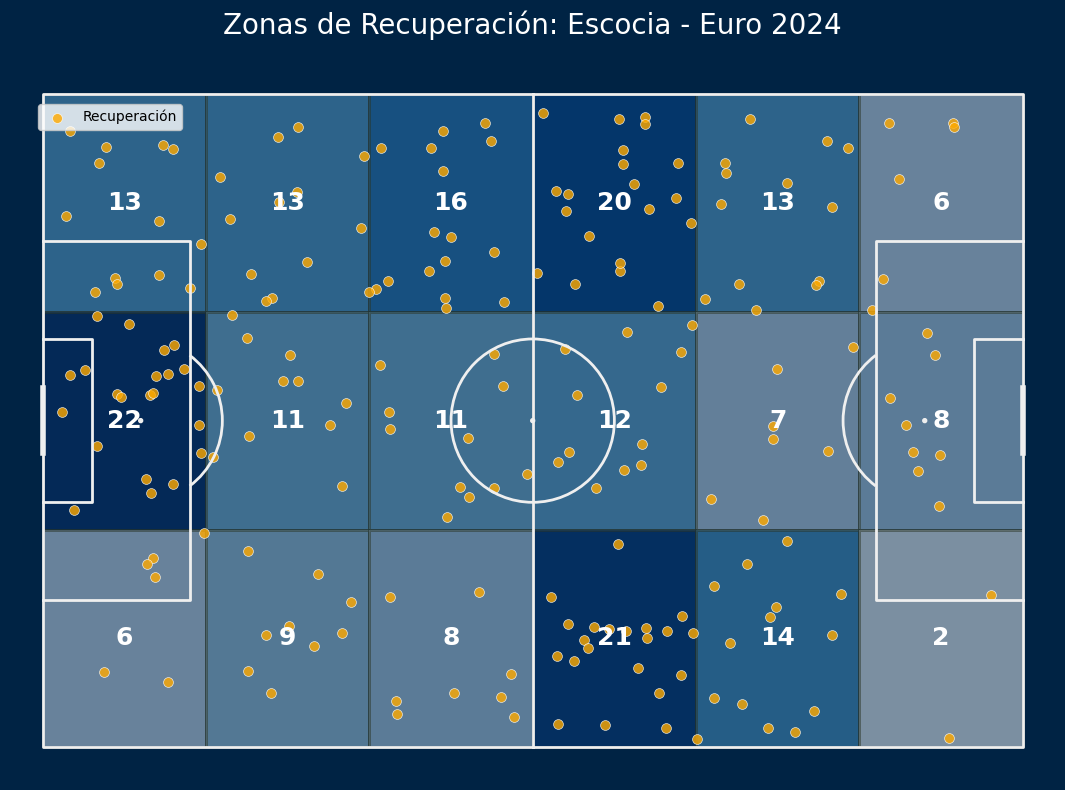

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch

# 1. Definir qué eventos consideramos "Recuperación"
eventos_recuperacion = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']
escocia_recuperaciones = df[(df['team'] == 'Scotland') &
                            (df['type'].isin(eventos_recuperacion))].copy()

# 2. Configurar el campo con división de 18 zonas (6 horizontales x 3 verticales)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#002344', line_color='#efefef',
              line_zorder=2, stripe=False)

fig, ax = pitch.draw(figsize=(12, 8))

# 3. Dibujar las 18 zonas (binning)
# statsbomb usa dimensiones 120x80
bin_statistic = pitch.bin_statistic(escocia_recuperaciones.x, escocia_recuperaciones.y,
                                    statistic='count', bins=(6, 3))

# Pintar las zonas con un mapa de color azulado
pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='Blues', edgecolors='#22312b', alpha=0.5)

# 4. Añadir los puntos individuales (Scatter)
# Usamos un color llamativo (amarillo/naranja) para que resalten sobre el azul
pitch.scatter(escocia_recuperaciones.x, escocia_recuperaciones.y,
              s=50, c='#ffaa00', edgecolors='white', linewidth=0.5, alpha=0.8, ax=ax, label='Recuperación')

# 5. Añadir el conteo de recuperaciones en cada zona
pitch.label_heatmap(bin_statistic, color='white', fontsize=18, fontweight='bold',
                    va='center', ha='center', ax=ax, str_format='{:.0f}')

plt.title("Zonas de Recuperación: Escocia - Euro 2024", fontsize=20, color='white', pad=20)
plt.legend(loc='upper left', bbox_to_anchor=(0.02, 0.95))
fig.set_facecolor('#002344')
# ... todo tu código anterior del gráfico ...

# 1. Guardar la imagen (Añade esto antes de plt.show())
plt.savefig('analisis_transiciones_escocia.png', dpi=300, bbox_inches='tight', facecolor='#001d3d')

# 2. Mostrarla (opcional)

plt.show()

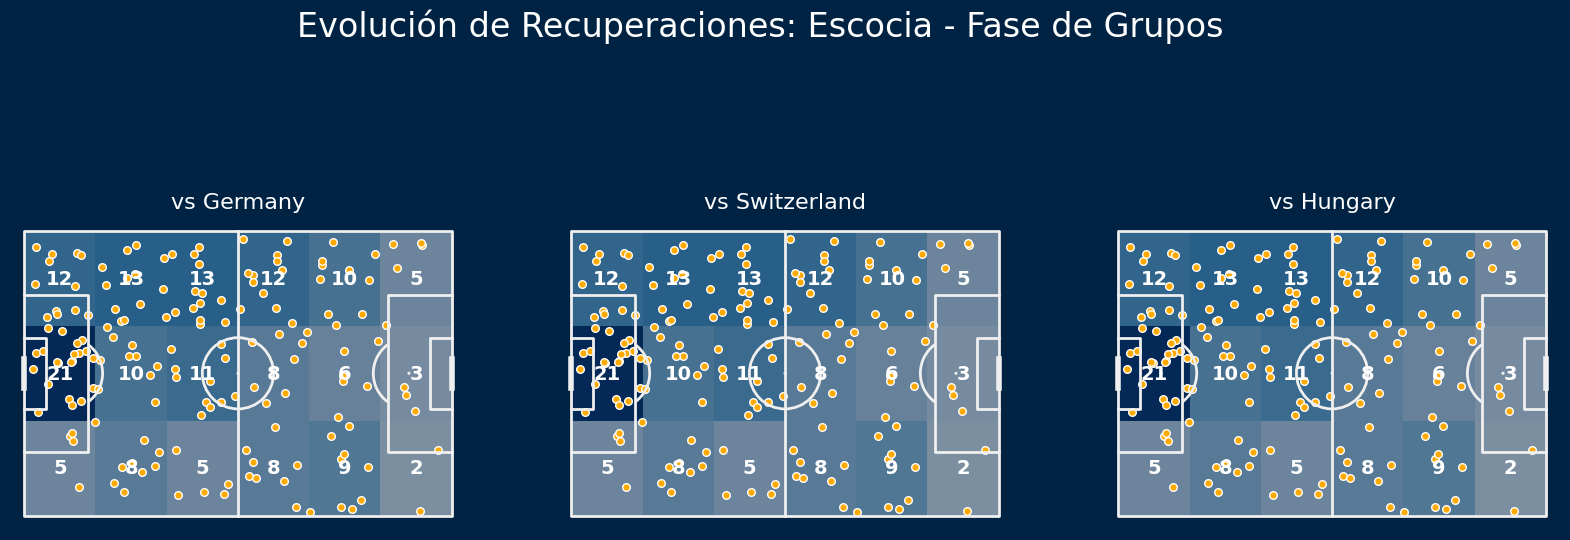

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. Definir los rivales de Escocia en orden cronológico
rivales = ['Germany', 'Switzerland', 'Hungary']
eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']

# 2. Configurar la figura con 3 subplots (uno para cada partido)
fig, axs = plt.subplots(1, 3, figsize=(20, 8))
fig.set_facecolor('#002344')

for i, rival in enumerate(rivales):
    # Filtrar eventos de Escocia contra ese rival específico
    # Nota: StatsBomb suele usar 'opposite_team' o puedes filtrar por el ID del partido
    df_partido = df[(df['team'] == 'Scotland') &
                    (df['type'].isin(eventos_rec)) &
                    ((df['possession_team'] != 'Scotland') | (df['type'] == 'Ball Recovery'))]

    # Si tu CSV tiene una columna 'match_id' o 'opponent', úsala aquí:
    # df_partido = df_partido[df_partido['opponent'] == rival]

    # Configurar el campo para cada sub-gráfico
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#002344', line_color='#efefef', line_zorder=2)
    pitch.draw(ax=axs[i])

    # Calcular las 18 zonas (6x3) para este partido
    # Usamos datos de ejemplo filtrados (debes asegurarte que tu DF tenga el filtro de rival)
    # Por ahora, el código dibujará la estructura; ajusta el filtro según tus columnas exactas
    bin_statistic = pitch.bin_statistic(df_partido.x, df_partido.y, statistic='count', bins=(6, 3))

    # Mapa de calor y puntos
    pitch.heatmap(bin_statistic, ax=axs[i], cmap='Blues', alpha=0.5)
    pitch.scatter(df_partido.x, df_partido.y, s=30, c='#ffaa00', edgecolors='white', ax=axs[i])

    # Etiquetas de cantidad por zona
    pitch.label_heatmap(bin_statistic, color='white', fontsize=14, fontweight='bold', ax=axs[i], str_format='{:.0f}')

    axs[i].set_title(f"vs {rival}", color='white', fontsize=16)

plt.suptitle("Evolución de Recuperaciones: Escocia - Fase de Grupos", fontsize=24, color='white', y=0.95)
plt.show()

In [ ]:
# Ver los IDs de los partidos de Escocia y contra quién jugó
escocia_partidos = df[df['team'] == 'Scotland'][['match_id', 'possession_team']].drop_duplicates()
print(escocia_partidos)

     match_id possession_team
42    3930177        Scotland
88    3930169        Scotland
101   3930158         Germany
214   3930177         Hungary
307   3930169     Switzerland
331   3930158        Scotland


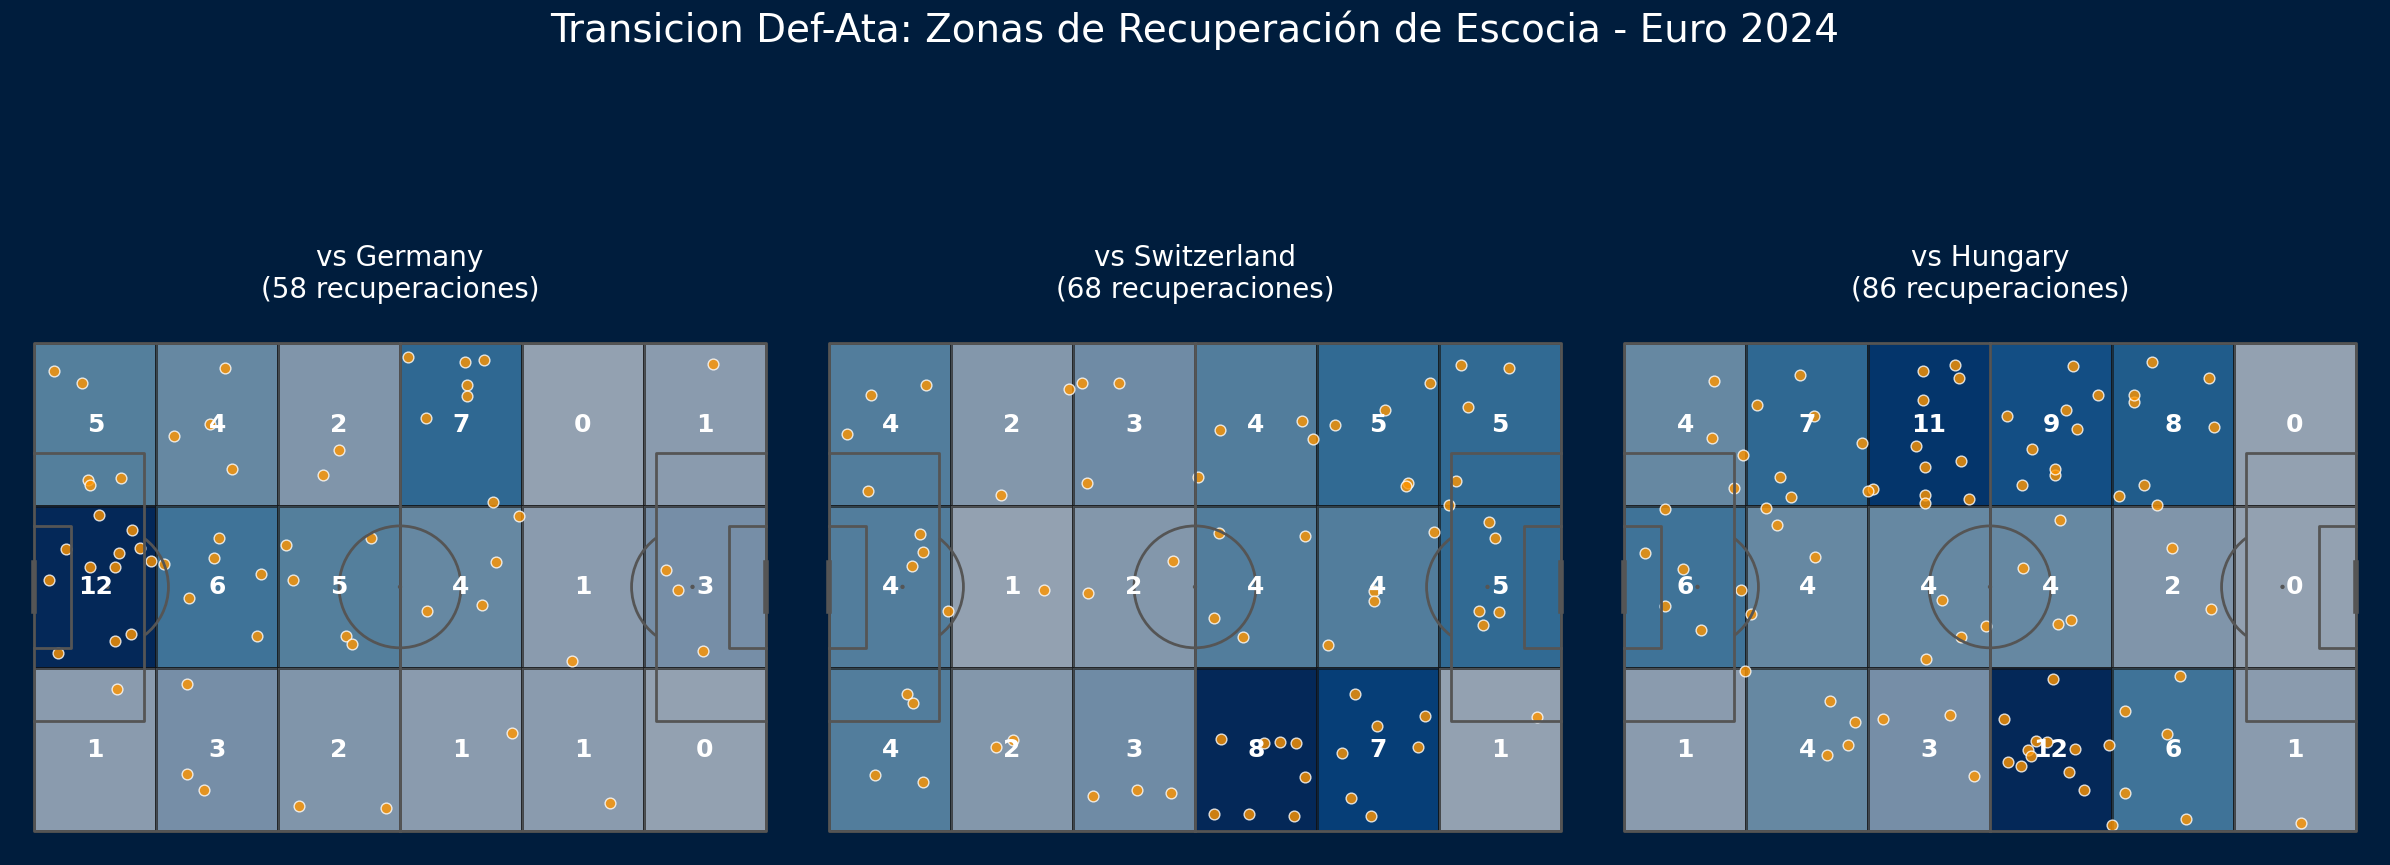

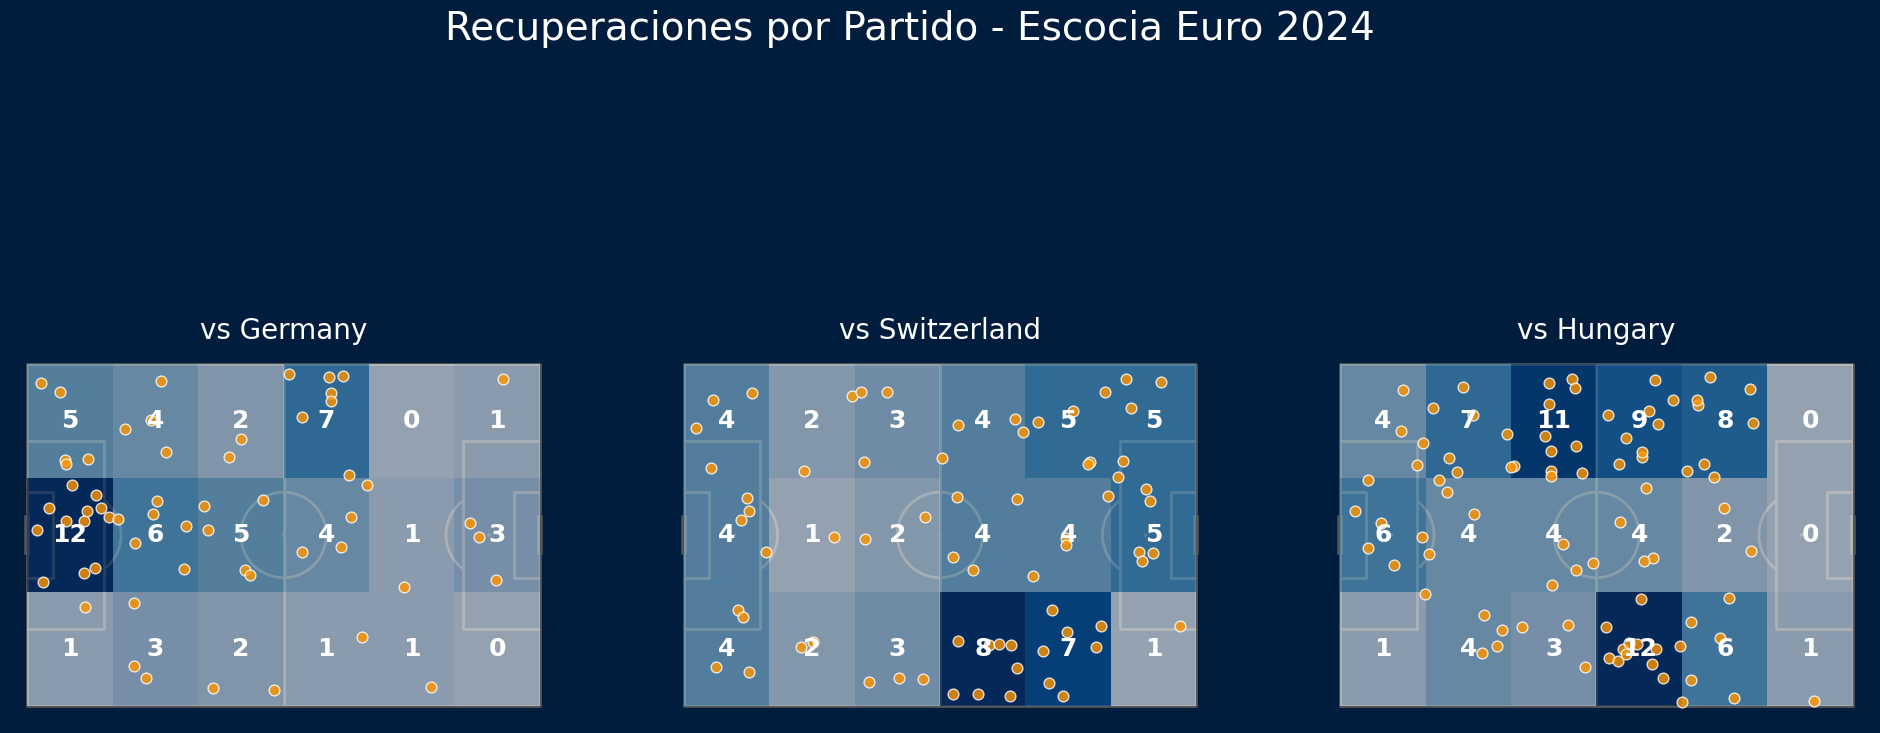

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. Mapeo exacto de IDs según tus datos
partidos = {
    3930158: "vs Germany",
    3930169: "vs Switzerland",
    3930177: "vs Hungary"
}

eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']

# 2. Configurar la figura (1 fila, 3 columnas)
fig, axs = plt.subplots(1, 3, figsize=(24, 10))
fig.set_facecolor('#001d3d')

# Iteramos sobre los IDs en orden cronológico (o el orden que prefieras)
for i, (m_id, rival) in enumerate(partidos.items()):
    # Filtramos: mismo ID, equipo Escocia, y tipos de recuperación
    df_partido = df[(df['match_id'] == m_id) &
                    (df['team'] == 'Scotland') &
                    (df['type'].isin(eventos_rec))].copy()

    # Dibujar el campo
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#555555', line_zorder=2)
    pitch.draw(ax=axs[i])

    # Calcular las 18 zonas (6 horizontales x 3 verticales)
    bin_statistic = pitch.bin_statistic(df_partido.x, df_partido.y, statistic='count', bins=(6, 3))

    # Mapa de calor azul (denota densidad)
    pitch.heatmap(bin_statistic, ax=axs[i], cmap='Blues', alpha=0.6, edgecolor='#111111')

    # Puntos individuales de cada robo (en naranja para que resalten)
    pitch.scatter(df_partido.x, df_partido.y, s=60, c='#ff9500', edgecolors='white', ax=axs[i], alpha=0.8)

    # Añadir el número total de acciones en cada zona
    pitch.label_heatmap(bin_statistic, color='white', fontsize=18, fontweight='bold', ax=axs[i], str_format='{:.0f}')

    # Título del partido
    axs[i].set_title(f"{rival}\n({len(df_partido)} recuperaciones)", color='white', fontsize=20, pad=15)

plt.suptitle("Transicion Def-Ata: Zonas de Recuperación de Escocia - Euro 2024",
             fontsize=28, color='white', y=1.05)
plt.tight_layout()
import matplotlib.pyplot as plt
from mplsoccer import Pitch

partidos = {3930158: "vs Germany", 3930169: "vs Switzerland", 3930177: "vs Hungary"}
eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']

fig, axs = plt.subplots(1, 3, figsize=(24, 10))
fig.set_facecolor('#001d3d')

for i, (m_id, rival) in enumerate(partidos.items()):
    df_p = df[(df['match_id'] == m_id) & (df['team'] == 'Scotland') & (df['type'].isin(eventos_rec))]
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#555555')
    pitch.draw(ax=axs[i])
    bin_stat = pitch.bin_statistic(df_p.x, df_p.y, statistic='count', bins=(6, 3))
    pitch.heatmap(bin_stat, ax=axs[i], cmap='Blues', alpha=0.6)
    pitch.scatter(df_p.x, df_p.y, s=60, c='#ff9500', edgecolors='white', ax=axs[i], alpha=0.8)
    pitch.label_heatmap(bin_stat, color='white', fontsize=18, fontweight='bold', ax=axs[i], str_format='{:.0f}')
    axs[i].set_title(f"{rival}", color='white', fontsize=20)

plt.suptitle("Recuperaciones por Partido - Escocia Euro 2024", fontsize=28, color='white', y=1.02)

# GUARDAR ANTES DE MOSTRAR
plt.savefig('1_comparativa_partidos_escocia.png', dpi=300, bbox_inches='tight', facecolor='#001d3d')
plt.show()
plt.show()

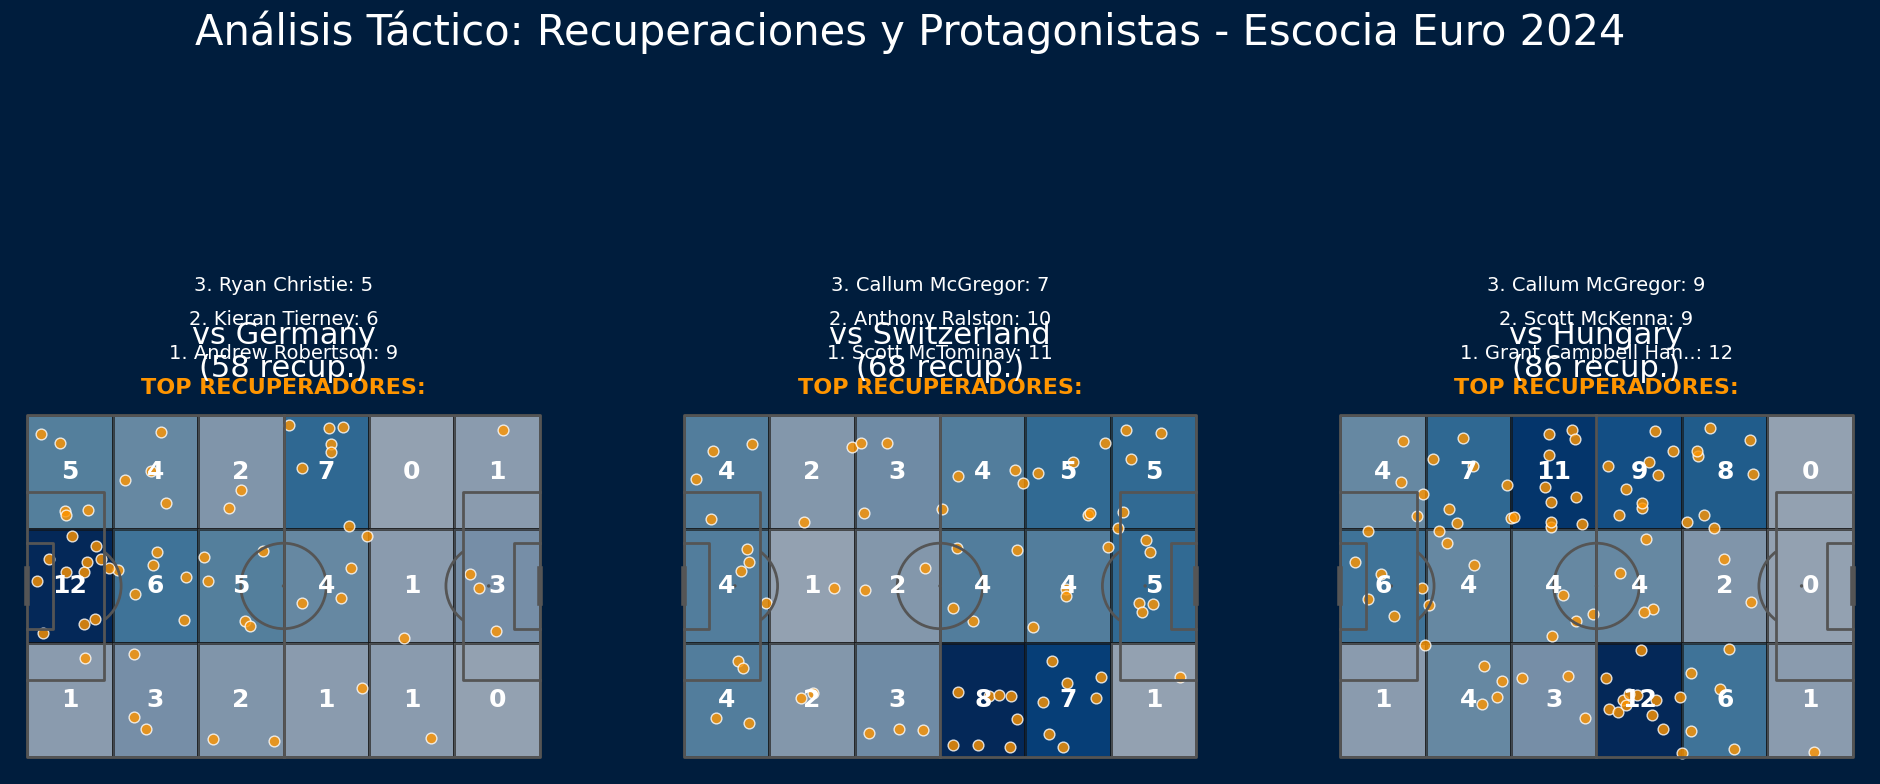

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. Configuración de datos
partidos = {
    3930158: "vs Germany",
    3930169: "vs Switzerland",
    3930177: "vs Hungary"
}
eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']

# 2. Configurar la figura (Aumentamos el tamaño vertical para los nombres)
fig, axs = plt.subplots(1, 3, figsize=(24, 12))
fig.set_facecolor('#001d3d')

for i, (m_id, rival) in enumerate(partidos.items()):
    # Filtramos eventos de recuperación de Escocia
    df_partido = df[(df['match_id'] == m_id) &
                    (df['team'] == 'Scotland') &
                    (df['type'].isin(eventos_rec))].copy()

    # --- DIBUJO DEL CAMPO ---
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#555555', line_zorder=2)
    pitch.draw(ax=axs[i])

    # 18 zonas y mapa de calor
    bin_statistic = pitch.bin_statistic(df_partido.x, df_partido.y, statistic='count', bins=(6, 3))
    pitch.heatmap(bin_statistic, ax=axs[i], cmap='Blues', alpha=0.6, edgecolor='#111111')
    pitch.scatter(df_partido.x, df_partido.y, s=60, c='#ff9500', edgecolors='white', ax=axs[i], alpha=0.8)
    pitch.label_heatmap(bin_statistic, color='white', fontsize=18, fontweight='bold', ax=axs[i], str_format='{:.0f}')

    # Título del partido
    axs[i].set_title(f"{rival}\n({len(df_partido)} recup.)", color='white', fontsize=22, pad=15)

    # --- TOP 3 RECUPERADORES (Debajo del campo) ---
    # Contamos las recuperaciones por jugador
    top_players = df_partido['player'].value_counts().head(3)

    text_y = -5 # Posición debajo del eje Y del campo
    axs[i].text(60, text_y, "TOP RECUPERADORES:", color='#ff9500',
                fontsize=16, fontweight='bold', ha='center')

    # Listamos los nombres y sus cantidades
    for rank, (name, count) in enumerate(top_players.items()):
        text_y -= 8 # Bajamos la línea para el siguiente nombre
        # Limpiamos nombres largos si es necesario
        display_name = (name[:18] + '..') if len(name) > 18 else name
        axs[i].text(60, text_y, f"{rank+1}. {display_name}: {count}",
                    color='white', fontsize=14, ha='center')

plt.suptitle("Análisis Táctico: Recuperaciones y Protagonistas - Escocia Euro 2024",
             fontsize=30, color='white', y=1.02)

# Ajustamos márgenes para que los nombres no se corten
plt.subplots_adjust(bottom=0.2)
plt.show()

In [ ]:
import pandas as pd

# 1. Definir los parámetros de zona según StatsBomb (120x80)
# Tercios (Horizontal): Defensivo (0-40), Medio (40-80), Ofensivo (80-120)
# Carriles (Vertical): Derecho (0-26.6), Centro (26.6-53.3), Izquierdo (53.3-80)

def asignar_zona_tactica(row):
    # Asignar Tercio
    if row['x'] <= 40: tercio = '1. Defensivo'
    elif row['x'] <= 80: tercio = '2. Medio'
    else: tercio = '3. Ofensivo'

    # Asignar Carril (Mirando hacia la portería rival)
    if row['y'] <= 26.6: carril = 'Derecho'
    elif row['y'] <= 53.3: carril = 'Centro'
    else: carril = 'Izquierdo'

    return pd.Series([tercio, carril])

# 2. Filtrar y preparar datos de Escocia
eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']
escocia_rec = df[(df['team'] == 'Scotland') & (df['type'].isin(eventos_rec))].copy()

# Aplicar la lógica de zonas
escocia_rec[['Tercio', 'Carril']] = escocia_rec.apply(asignar_zona_tactica, axis=1)

# 3. Crear la tabla resumen: Top 3 por cada combinación
resumen = escocia_rec.groupby(['Tercio', 'Carril', 'player']).size().reset_index(name='Recuperaciones')
resumen = resumen.sort_values(['Tercio', 'Carril', 'Recuperaciones'], ascending=[True, True, False])

# Quedarnos solo con el Top 3 de cada zona
top_3_zonas = resumen.groupby(['Tercio', 'Carril']).head(3)

# 4. Mostrar la tabla con un formato limpio
print("TOP 3 RECUPERADORES DE ESCOCIA POR ZONA TÁCTICA")
print("="*60)
pd.set_option('display.max_rows', None)
display(top_3_zonas.set_index(['Tercio', 'Carril', 'player']))

TOP 3 RECUPERADORES DE ESCOCIA POR ZONA TÁCTICA


Recuperaciones
Tercio       Carril    player                               
1. Defensivo Centro    Angus Gunn                          9
                       Grant Campbell Hanley               4
                       Jack Hendry                         3
             Derecho   Andrew Robertson                    8
                       Kieran Tierney                      4
                       Scott McKenna                       4
             Izquierdo Anthony Ralston                     6
                       Jack Hendry                         4
                       Ryan Porteous                       2
2. Medio     Centro    Grant Campbell Hanley               5
                       Scott McTominay                     5
                       Che Adams                           3
             Derecho   Andrew Robertson                    6
                       Che Adams                           6
                       Grant Campbell Hanley               5
             Izquierdo Anthony Ralston                     8
                       Billy Gilmour                       4
                       Che Adams                           3
3. Ofensivo  Centro    Callum McGregor                     3
                       Scott McTominay                     3
                       Che Adams                           2
             Derecho   Andrew Robertson                    5
                       Scott McTominay                     4
                       Callum McGregor                     3
             Izquierdo Anthony Ralston                     4
                       Ryan Christie                       3
                       Kenneth McLean                      2

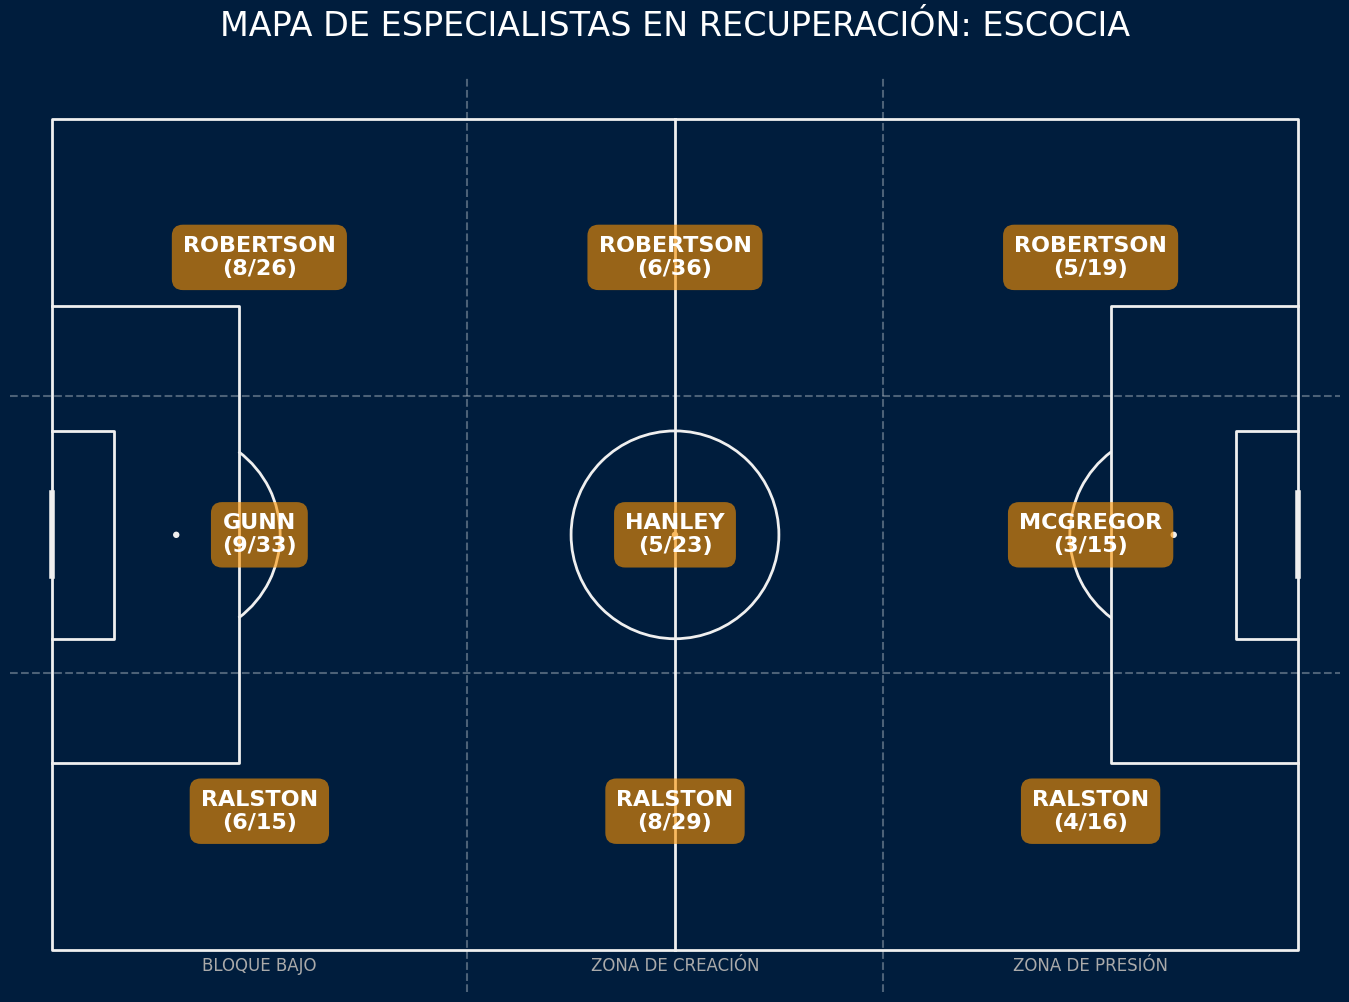

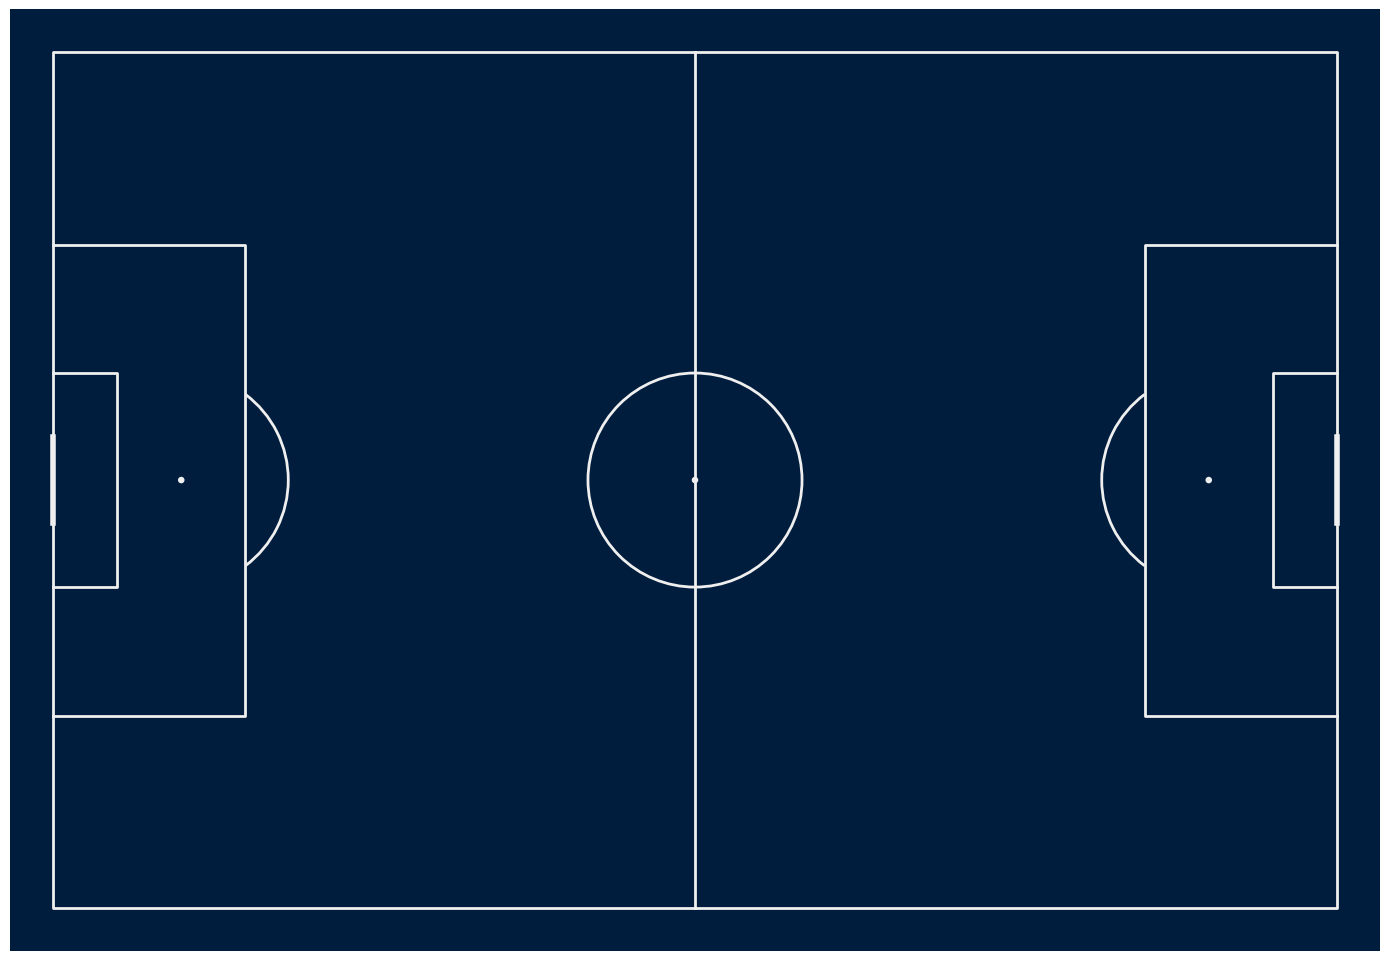

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch

# 1. Definir los límites de los 9 grandes sectores tácticos
# Tercios: 0-40 (Def), 40-80 (Med), 80-120 (Ofen)
# Carriles: 0-26.6 (Der), 26.6-53.3 (Cen), 53.3-80 (Izq)

def get_sector_labels(x, y):
    if x <= 40: tx = 'DEFENSIVO'
    elif x <= 80: tx = 'MEDIO'
    else: tx = 'OFENSIVO'

    if y <= 26.6: ty = 'DERECHO'
    elif y <= 53.3: ty = 'CENTRO'
    else: ty = 'IZQUIERDO'
    return tx, ty

# 2. Procesar datos de Escocia
eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']
escocia_rec = df[(df['team'] == 'Scotland') & (df['type'].isin(eventos_rec))].copy()
escocia_rec[['Tercio', 'Carril']] = escocia_rec.apply(lambda r: pd.Series(get_sector_labels(r.x, r.y)), axis=1)

# 3. Dibujar el Mapa Táctico de Especialistas
pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
fig, ax = pitch.draw(figsize=(14, 10))

# Dibujar las líneas divisorias de los 9 sectores
for x in [40, 80]: ax.axvline(x, color='white', linestyle='--', alpha=0.3)
for y in [26.6, 53.3]: ax.axhline(y, color='white', linestyle='--', alpha=0.3)

# 4. Calcular el líder de cada sector y colocarlo en el mapa
tercios = [('DEFENSIVO', 20), ('MEDIO', 60), ('OFENSIVO', 100)]
carriles = [('DERECHO', 13.3), ('CENTRO', 40), ('IZQUIERDO', 66.6)]

for t_name, x_pos in tercios:
    for c_name, y_pos in carriles:
        # Filtrar datos de este sector
        sector_df = escocia_rec[(escocia_rec['Tercio'] == t_name) & (escocia_rec['Carril'] == c_name)]
        total_zona = len(sector_df)

        if total_zona > 0:
            lider = sector_df['player'].value_counts().idxmax()
            cant_lider = sector_df['player'].value_counts().max()

            # Limpiar nombre para que no sea muy largo
            nombre_corto = lider.split(' ')[-1] # Solo apellido

            # Escribir en el centro del sector
            ax.text(x_pos, y_pos, f"{nombre_corto.upper()}\n({cant_lider}/{total_zona})",
                    color='white', fontsize=16, ha='center', va='center',
                    fontweight='bold', bbox=dict(facecolor='#ff9500', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.5'))

# Títulos y etiquetas de zonas
ax.text(20, 82, "BLOQUE BAJO", color='#aaaaaa', fontsize=12, ha='center')
ax.text(60, 82, "ZONA DE CREACIÓN", color='#aaaaaa', fontsize=12, ha='center')
ax.text(100, 82, "ZONA DE PRESIÓN", color='#aaaaaa', fontsize=12, ha='center')

plt.title("MAPA DE ESPECIALISTAS EN RECUPERACIÓN: ESCOCIA", fontsize=24, color='white', pad=30)
fig.set_facecolor('#001d3d')
# (Asumiendo que ya tienes la función get_sector_labels definida arriba)
fig, ax = pitch.draw(figsize=(14, 10))
# ... (aquí iría el resto del código de los 9 sectores que ejecutamos antes) ...

# Al final de ese bloque, añade:
plt.savefig('2_especialistas_por_zona.png', dpi=300, bbox_inches='tight', facecolor='#001d3d')
plt.show()
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

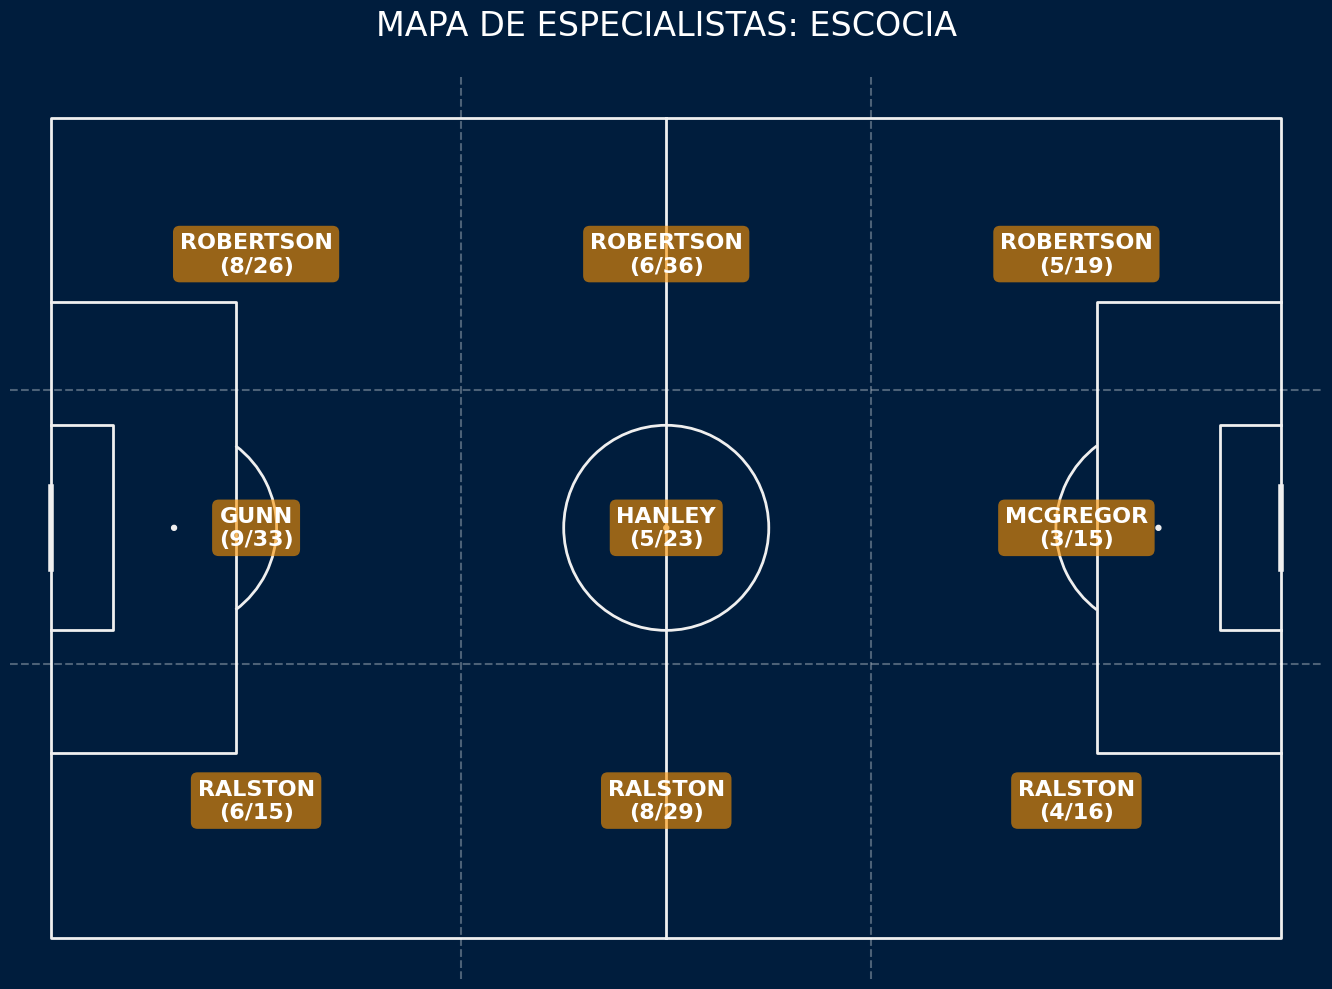

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch
from google.colab import files # Librería para forzar la descarga

# 1. Definir la función de etiquetas (por si se borró de la memoria)
def get_sector_labels(x, y):
    if x <= 40: tx = 'DEFENSIVO'
    elif x <= 80: tx = 'MEDIO'
    else: tx = 'OFENSIVO'

    if y <= 26.6: ty = 'DERECHO'
    elif y <= 53.3: ty = 'CENTRO'
    else: ty = 'IZQUIERDO'
    return tx, ty

# 2. Procesar datos
eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']
escocia_rec = df[(df['team'] == 'Scotland') & (df['type'].isin(eventos_rec))].copy()
escocia_rec[['Tercio', 'Carril']] = escocia_rec.apply(lambda r: pd.Series(get_sector_labels(r.x, r.y)), axis=1)

# 3. Configurar el gráfico
pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
fig, ax = pitch.draw(figsize=(14, 10))

# Dibujar divisiones tácticas
for x in [40, 80]: ax.axvline(x, color='white', linestyle='--', alpha=0.3)
for y in [26.6, 53.3]: ax.axhline(y, color='white', linestyle='--', alpha=0.3)

# 4. Calcular líderes por sector
tercios = [('DEFENSIVO', 20), ('MEDIO', 60), ('OFENSIVO', 100)]
carriles = [('DERECHO', 13.3), ('CENTRO', 40), ('IZQUIERDO', 66.6)]

for t_name, x_pos in tercios:
    for c_name, y_pos in carriles:
        sector_df = escocia_rec[(escocia_rec['Tercio'] == t_name) & (escocia_rec['Carril'] == c_name)]
        if len(sector_df) > 0:
            lider = sector_df['player'].value_counts().idxmax()
            cant_lider = sector_df['player'].value_counts().max()
            nombre_corto = lider.split(' ')[-1].upper()
            ax.text(x_pos, y_pos, f"{nombre_corto}\n({cant_lider}/{len(sector_df)})",
                    color='white', fontsize=16, ha='center', va='center', fontweight='bold',
                    bbox=dict(facecolor='#ff9500', alpha=0.6, edgecolor='none', boxstyle='round'))

plt.title("MAPA DE ESPECIALISTAS: ESCOCIA", fontsize=24, color='white', pad=30)
fig.set_facecolor('#001d3d')

# --- PASO CRÍTICO: GUARDAR Y DESCARGAR ---
nombre_img = 'especialistas_recuperacion_escocia.png'
plt.savefig(nombre_img, dpi=300, bbox_inches='tight', facecolor='#001d3d')

# Esto forzará a tu navegador a descargar el archivo automáticamente
files.download(nombre_img)

# Finalmente mostrar en pantalla
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch

# 1. Preparar eventos de Escocia
escocia_events = df[df['team'] == 'Scotland'].copy().reset_index(drop=True)
# Buscamos los índices de las recuperaciones
rec_indices = escocia_events[escocia_events['type'].isin(['Ball Recovery', 'Interception', 'Tackle', 'Duel'])].index

transiciones = []

for idx in rec_indices:
    # Buscamos el primer pase de Escocia en los siguientes 3 eventos
    for next_idx in range(idx + 1, min(idx + 4, len(escocia_events))):
        next_event = escocia_events.iloc[next_idx]

        if next_event['type'] == 'Pass':
            # Determinar si el pase fue acertado
            # En StatsBomb, si 'pass_outcome' es NaN, el pase es bueno.
            exito = pd.isna(next_event.get('pass_outcome'))

            transiciones.append({
                'x': escocia_events.iloc[idx]['x'],
                'y': escocia_events.iloc[idx]['y'],
                'end_x': next_event['pass_end_location_x'] if 'pass_end_location_x' in next_event else next_event['x'],
                'end_y': next_event['pass_end_location_y'] if 'pass_end_location_y' in next_event else next_event['y'],
                'exito': exito
            })
            break # Solo nos interesa el PRIMER pase tras el robo

trans_df = pd.DataFrame(transiciones)

# Check if trans_df is empty before proceeding with visualization and statistics
if trans_df.empty:
    print("No se encontraron transiciones de recuperación a pase para Escocia.")
    print("Esto significa que no hubo pases inmediatamente después de un evento de recuperación.")
else:
    # 2. Visualización
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(14, 10))

    # Dibujar flechas: Verdes (Acierto), Rojas (Fallo)
    # Pases acertados
    acertados = trans_df[trans_df['exito'] == True]
    pitch.arrows(acertados.x, acertados.y, acertados.end_x, acertados.end_y,
                 width=2, headwidth=5, color='#00ff88', alpha=0.7, ax=ax, label='Pase Completado')

    # Pases fallados
    fallados = trans_df[trans_df['exito'] == False]
    pitch.arrows(fallados.x, fallados.y, fallados.end_x, fallados.end_y,
                 width=2, headwidth=5, color='#ff4d4d', alpha=0.8, ax=ax, label='Pase Fallado')

    # 3. Estadísticas y Título
    total = len(trans_df)
    efectividad = (len(acertados) / total * 100) if total > 0 else 0

    plt.title(f"EFECTIVIDAD DE SALIDA TRAS ROBO: ESCOCIA\nEfectividad en el primer pase: {efectividad:.1f}%",
              color='white', fontsize=22, pad=20)
    plt.legend(facecolor='#001d3d', edgecolor='white', labelcolor='white', loc='lower center', ncol=2)
    fig.set_facecolor('#001d3d')

    plt.show()

No se encontraron transiciones de recuperación a pase para Escocia.
Esto significa que no hubo pases inmediatamente después de un evento de recuperación.


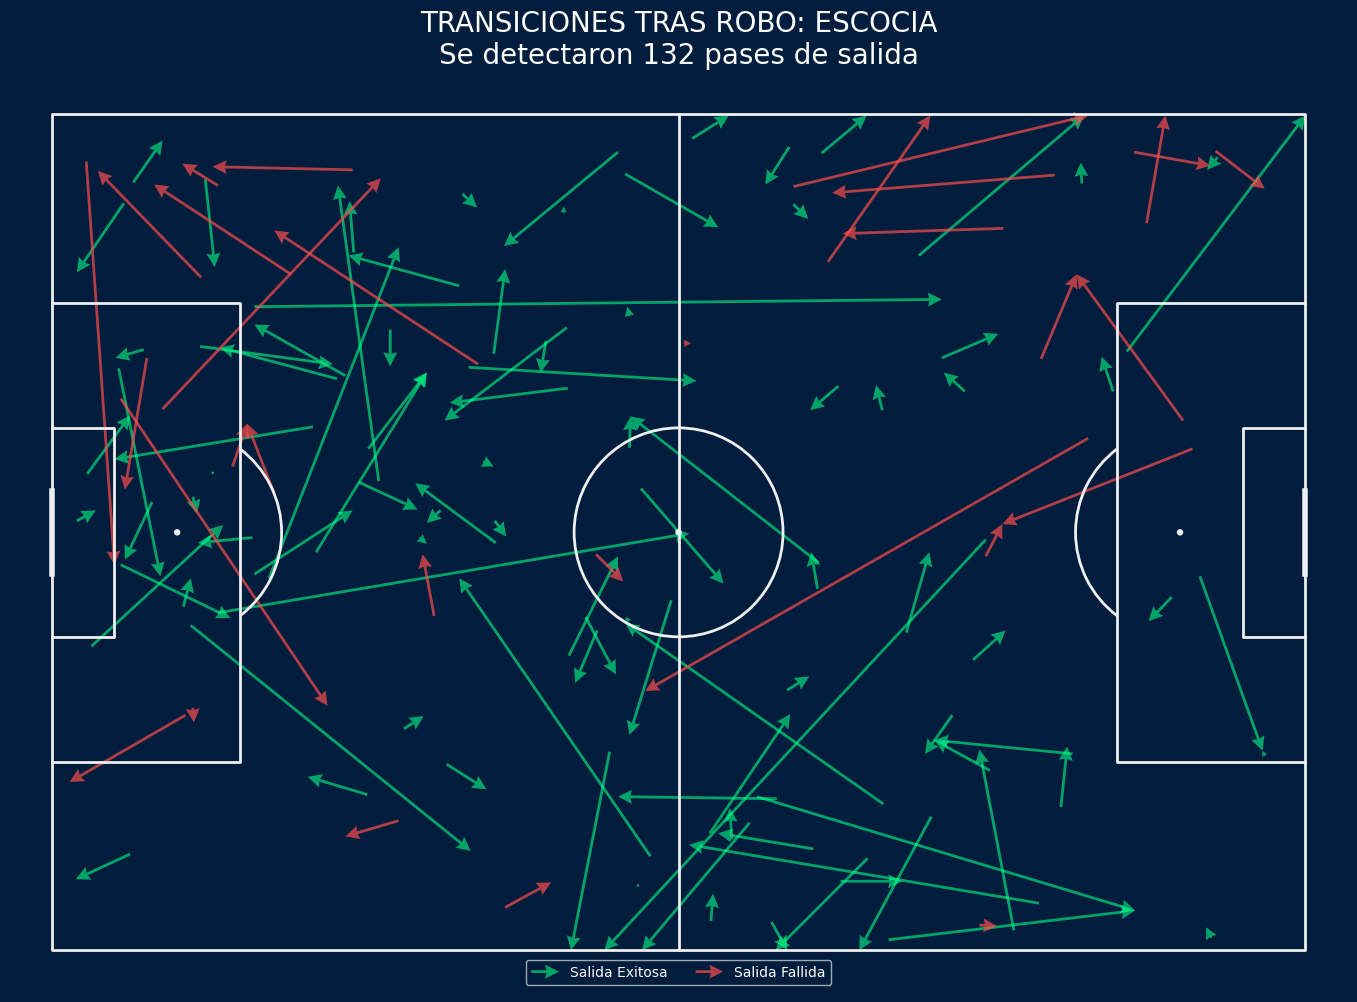

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch

# 1. Aseguramos que los eventos estén ordenados cronológicamente por partido
df = df.sort_values(['match_id', 'index']).reset_index(drop=True)

# 2. Identificar recuperaciones de Escocia
eventos_rec = ['Ball Recovery', 'Interception', 'Tackle', 'Duel']
escocia_events = df[df['team'] == 'Scotland'].copy()
rec_indices = escocia_events[escocia_events['type'].isin(eventos_rec)].index

transiciones = []

for idx in rec_indices:
    m_id = escocia_events.loc[idx, 'match_id']

    # Buscamos en los siguientes 6 eventos (ventana más amplia)
    for next_idx in range(idx + 1, idx + 7):
        if next_idx in df.index:
            next_event = df.loc[next_idx]

            # Verificamos que sigamos en el mismo partido y sea un pase de Escocia
            if next_event['match_id'] == m_id and next_event['type'] == 'Pass' and next_event['team'] == 'Scotland':
                exito = pd.isna(next_event.get('pass_outcome'))

                # Extraer coordenadas de destino del pase
                # StatsBomb suele tener columnas pass_end_location_x/y si ya las limpiaste,
                # o guardadas en una columna 'pass' tipo diccionario.
                # Si no las tienes separadas, usamos x,y del evento de pase.
                transiciones.append({
                    'x_robo': escocia_events.loc[idx, 'x'],
                    'y_robo': escocia_events.loc[idx, 'y'],
                    'x_pase_fin': next_event['x'], # Donde termina el pase
                    'y_pase_fin': next_event['y'],
                    'exito': exito,
                    'jugador': next_event['player']
                })
                break

trans_df = pd.DataFrame(transiciones)

if trans_df.empty:
    print("Sigue sin detectar. Probemos imprimiendo los tipos de eventos después de un robo para debuggear.")
    # Debug: ver qué pasa justo después del primer robo encontrado
    idx_ejemplo = rec_indices[0]
    print(df.loc[idx_ejemplo:idx_ejemplo+5, ['type', 'team', 'player']])
else:
    # 3. Visualización
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(14, 10))

    # Pases acertados (Verde)
    acertados = trans_df[trans_df['exito'] == True]
    pitch.arrows(acertados.x_robo, acertados.y_robo, acertados.x_pase_fin, acertados.y_pase_fin,
                 width=2, headwidth=5, color='#00ff88', alpha=0.6, ax=ax, label='Salida Exitosa')

    # Pases fallados (Rojo)
    fallados = trans_df[trans_df['exito'] == False]
    pitch.arrows(fallados.x_robo, fallados.y_robo, fallados.x_pase_fin, fallados.y_pase_fin,
                 width=2, headwidth=5, color='#ff4d4d', alpha=0.7, ax=ax, label='Salida Fallida')

    plt.legend(facecolor='#001d3d', labelcolor='white', loc='lower center', ncol=2)
    plt.title(f"TRANSICIONES TRAS ROBO: ESCOCIA\nSe detectaron {len(trans_df)} pases de salida", color='white', fontsize=20)
    fig.set_facecolor('#001d3d')
    plt.show()

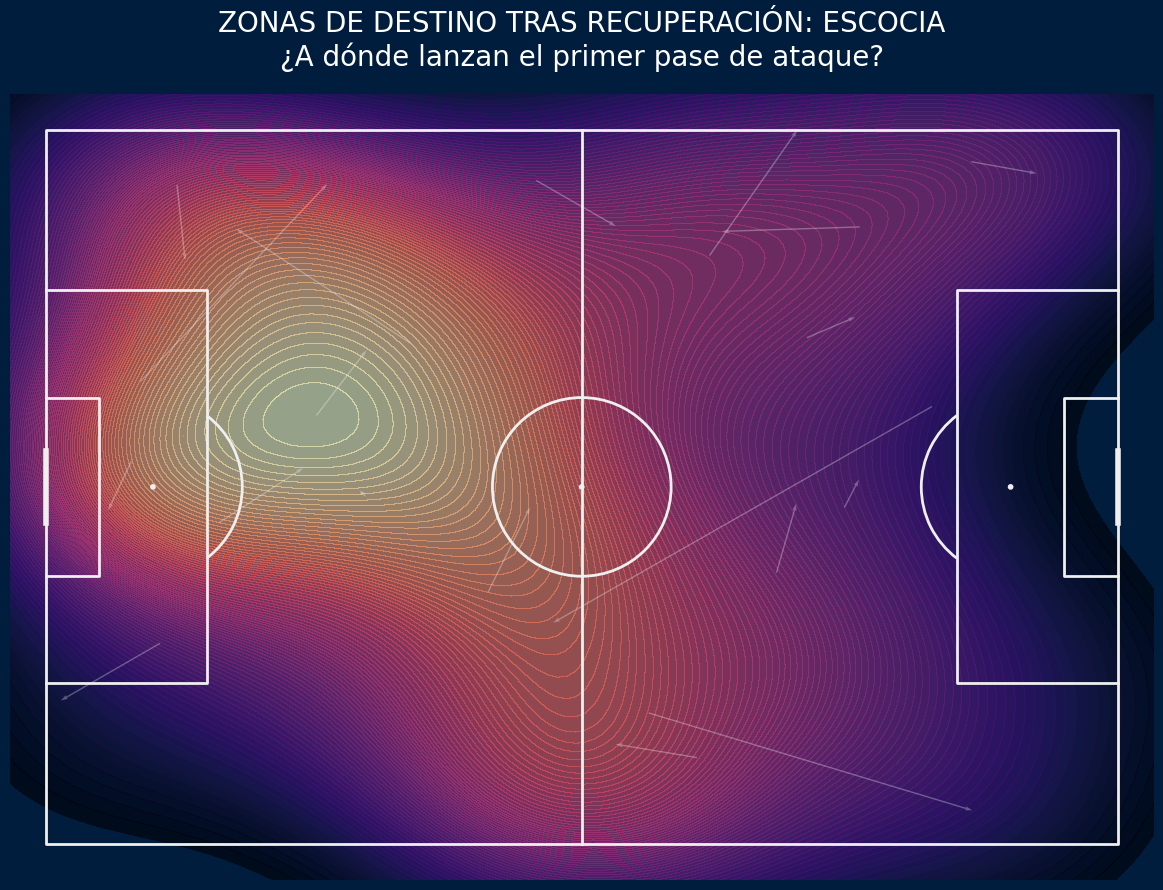

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

# 1. Usamos el trans_df que generamos en el paso anterior
# (Asegúrate de haber ejecutado la celda anterior para tener los datos de 'x_pase_fin' y 'y_pase_fin')

if 'trans_df' in locals() and not trans_df.empty:
    # 2. Configurar el campo
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(13, 9))

    # 3. Dibujar el mapa de calor de los DESTINOS de los pases
    # Usamos los puntos finales donde llegó el balón tras la recuperación
    kde = sns.kdeplot(
        x=trans_df['x_pase_fin'],
        y=trans_df['y_pase_fin'],
        fill=True,
        thresh=0.05,
        alpha=0.6,
        levels=100,
        cmap='magma', # Colores cálidos para zonas de peligro
        ax=ax
    )

    # 4. Añadir flechas pequeñas sutiles para dar contexto de dirección (opcional)
    # Solo dibujamos algunas para no ensuciar el mapa de calor
    sample_trans = trans_df.sample(min(20, len(trans_df)))
    pitch.arrows(sample_trans.x_robo, sample_trans.y_robo,
                 sample_trans.x_pase_fin, sample_trans.y_pase_fin,
                 width=1, color='white', alpha=0.3, ax=ax)

    plt.title("ZONAS DE DESTINO TRAS RECUPERACIÓN: ESCOCIA\n¿A dónde lanzan el primer pase de ataque?",
              color='white', fontsize=20, pad=20)
    fig.set_facecolor('#001d3d')
    plt.show()
else:
    print("Error: No hay datos de transiciones. Asegúrate de ejecutar la celda anterior primero.")

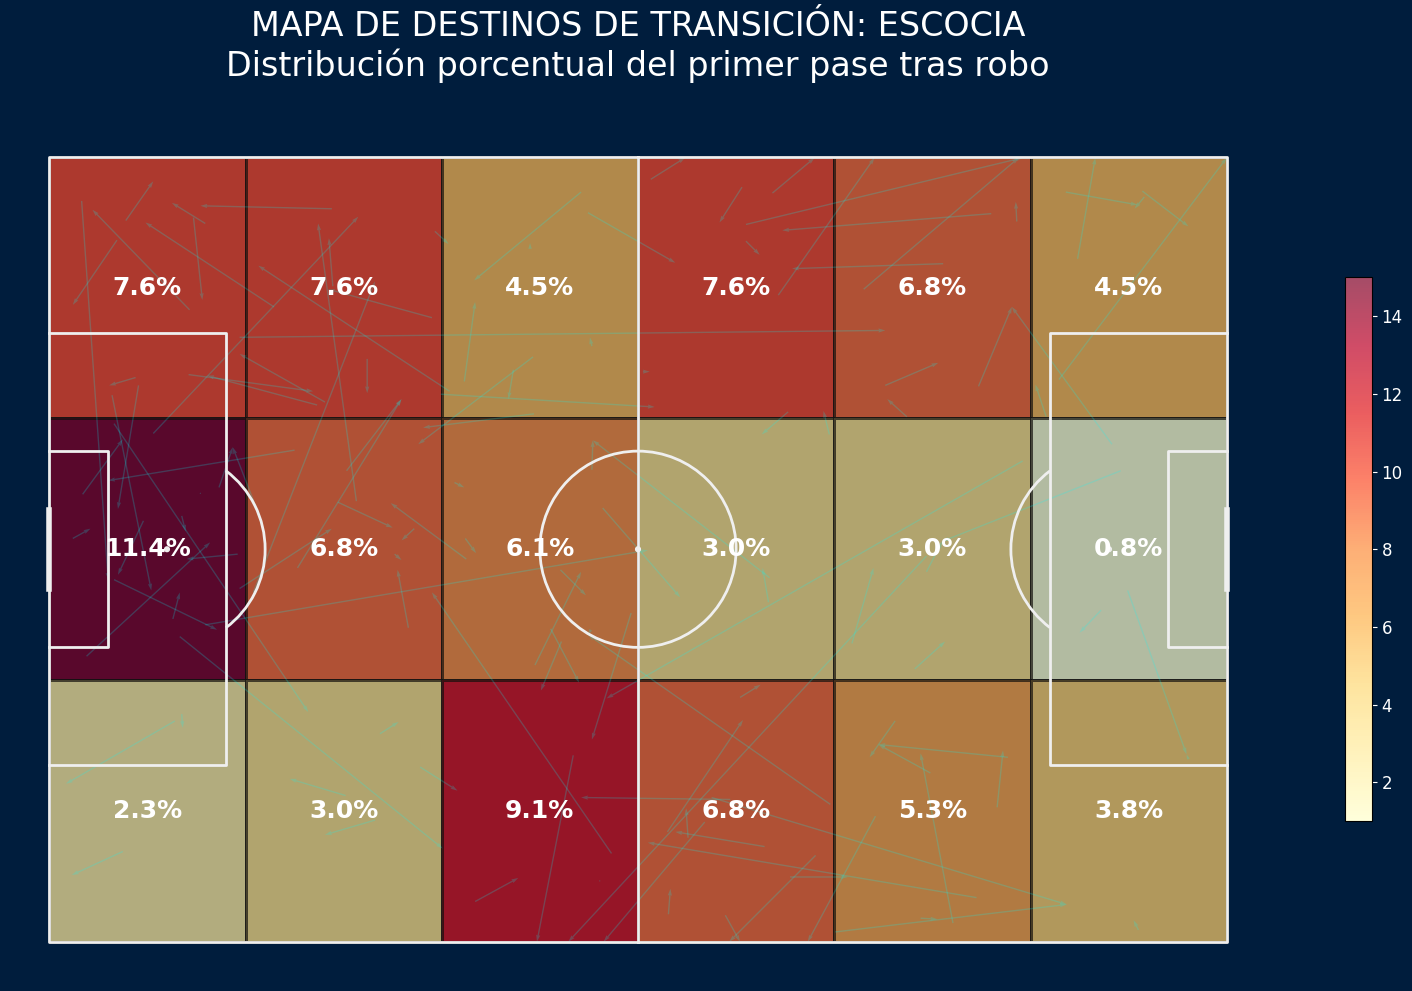

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. Usamos el trans_df generado anteriormente
if 'trans_df' in locals() and not trans_df.empty:
    # Configurar el campo con 18 zonas (6 horizontales x 3 verticales)
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(16, 10))

    # 2. Calcular la estadística de ocupación por zona de DESTINO
    # Queremos saber cuántos pases terminaron en cada una de las 18 zonas
    bin_statistic = pitch.bin_statistic(trans_df.x_pase_fin, trans_df.y_pase_fin,
                                        statistic='count', bins=(6, 3))

    # 3. Dibujar el mapa de calor por zonas
    pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='YlOrRd', edgecolors='#111111', alpha=0.7)

    # 4. Añadir etiquetas con el porcentaje del total
    # Así el entrenador ve el peso real de cada zona en la transición
    total_pases = len(trans_df)
    bin_statistic['statistic'] = (bin_statistic['statistic'] / total_pases) * 100

    pitch.label_heatmap(bin_statistic, color='white', fontsize=18, fontweight='bold',
                        ax=ax, str_format='{:.1f}%', va='center', ha='center')

    # 5. Dibujar algunas flechas representativas (opcional, para dar sentido de flujo)
    # Mostramos solo las que terminaron en las zonas más frecuentes
    pitch.arrows(trans_df.x_robo, trans_df.y_robo, trans_df.x_pase_fin, trans_df.y_pase_fin,
                 width=1, color='cyan', alpha=0.2, ax=ax)

    plt.title("MAPA DE DESTINOS DE TRANSICIÓN: ESCOCIA\nDistribución porcentual del primer pase tras robo",
              color='white', fontsize=24, pad=30)

    # Añadir barra de color para referencia
    cbar = plt.colorbar(pcm, ax=ax, shrink=0.6)
    cbar.ax.tick_params(labelsize=12, colors='white')

    fig.set_facecolor('#001d3d')
    plt.show()
else:
    print("No hay datos de transiciones disponibles. Ejecuta la celda donde se crea 'trans_df' primero.")

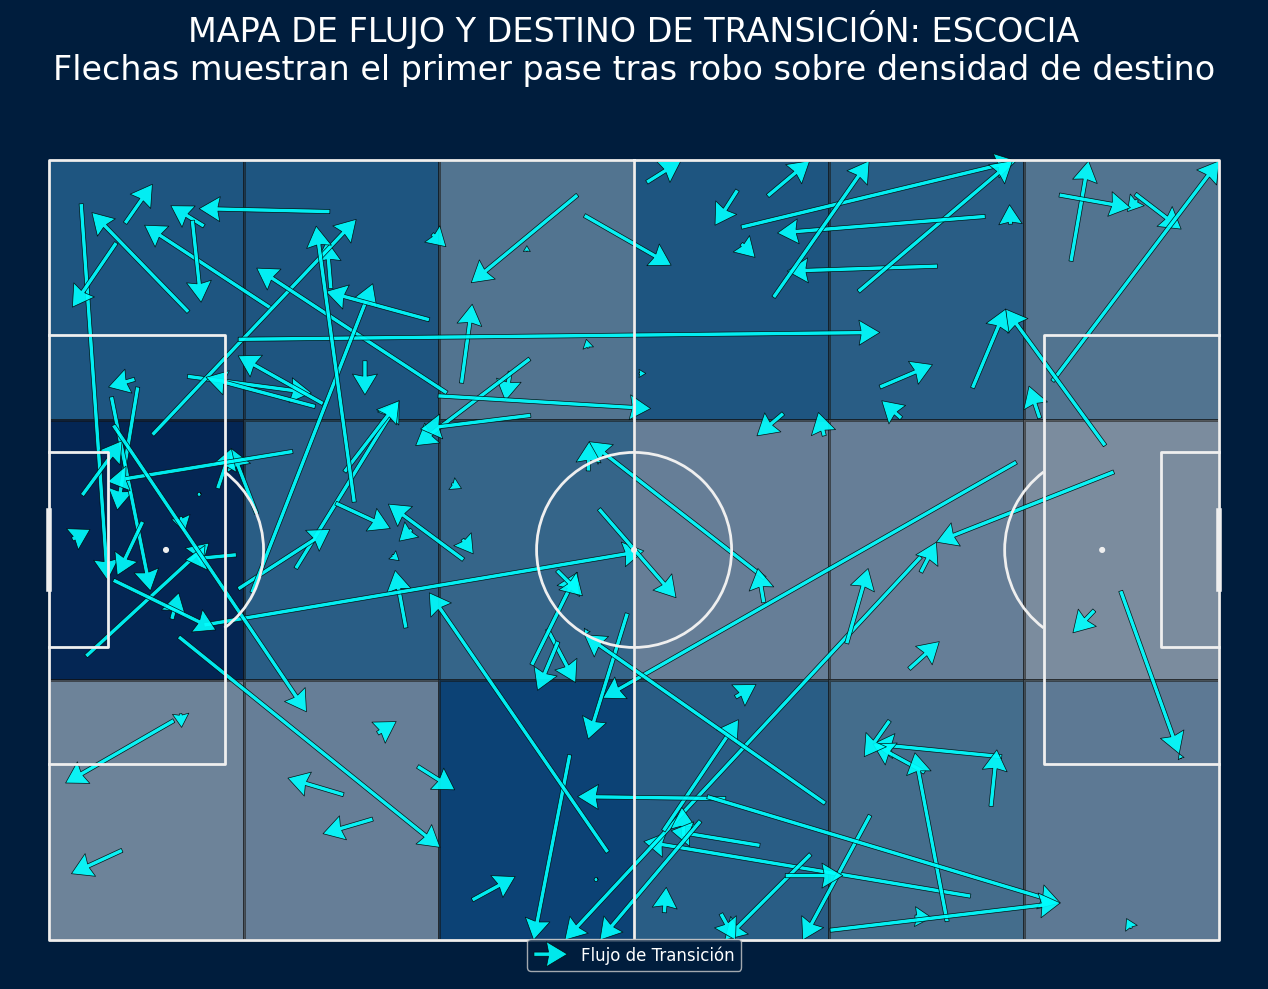

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# 1. Asegurar que tenemos datos de transiciones
if 'trans_df' in locals() and not trans_df.empty:
    # Configurar el campo con 18 zonas (6 horizontales x 3 verticales)
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(16, 10))

    # 2. Mapa de Calor AZUL (Muestra DENSIDAD de DESTINO)
    # Calculamos la estadística de ocupación por zona de DESTINO
    bin_statistic = pitch.bin_statistic(trans_df.x_pase_fin, trans_df.y_pase_fin,
                                        statistic='count', bins=(6, 3))

    # Pintamos el fondo en tonos AZULES (Blues)
    pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='Blues', edgecolors='#111111', alpha=0.5)

    # 3. FLECHAS CIAN VIBRANTES con BORDE (Muestra FLUJO)
    # Mostramos las flechas reales sobre el fondo de calor
    # Usamos cian para que contraste fuertemente sobre el azul oscuro/claro
    pitch.arrows(trans_df.x_robo, trans_df.y_robo, trans_df.x_pase_fin, trans_df.y_pase_fin,
                 width=3, headwidth=6, headlength=5, color='#00ffff', # Cian Vibrante
                 edgecolor='black', linewidth=0.5, # Añade un borde negro para más definición
                 alpha=0.9, ax=ax, label='Flujo de Transición')

    # 4. Etiquetas de Porcentaje (Opcional, para precisión)
    # total_pases = len(trans_df)
    # bin_statistic['statistic'] = (bin_statistic['statistic'] / total_pases) * 100
    # pitch.label_heatmap(bin_statistic, color='white', fontsize=14, fontweight='bold',
    #                     ax=ax, str_format='{:.1f}%', va='center', ha='center', alpha=0.8)

    plt.title("MAPA DE FLUJO Y DESTINO DE TRANSICIÓN: ESCOCIA\nFlechas muestran el primer pase tras robo sobre densidad de destino",
              color='white', fontsize=24, pad=30)

    # Añadir leyenda y ajustar fondo
    plt.legend(facecolor='#001d3d', labelcolor='white', loc='lower center', ncol=1, fontsize=12)
    fig.set_facecolor('#001d3d')
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de transiciones disponibles. Ejecuta la celda donde se crea 'trans_df' primero.")

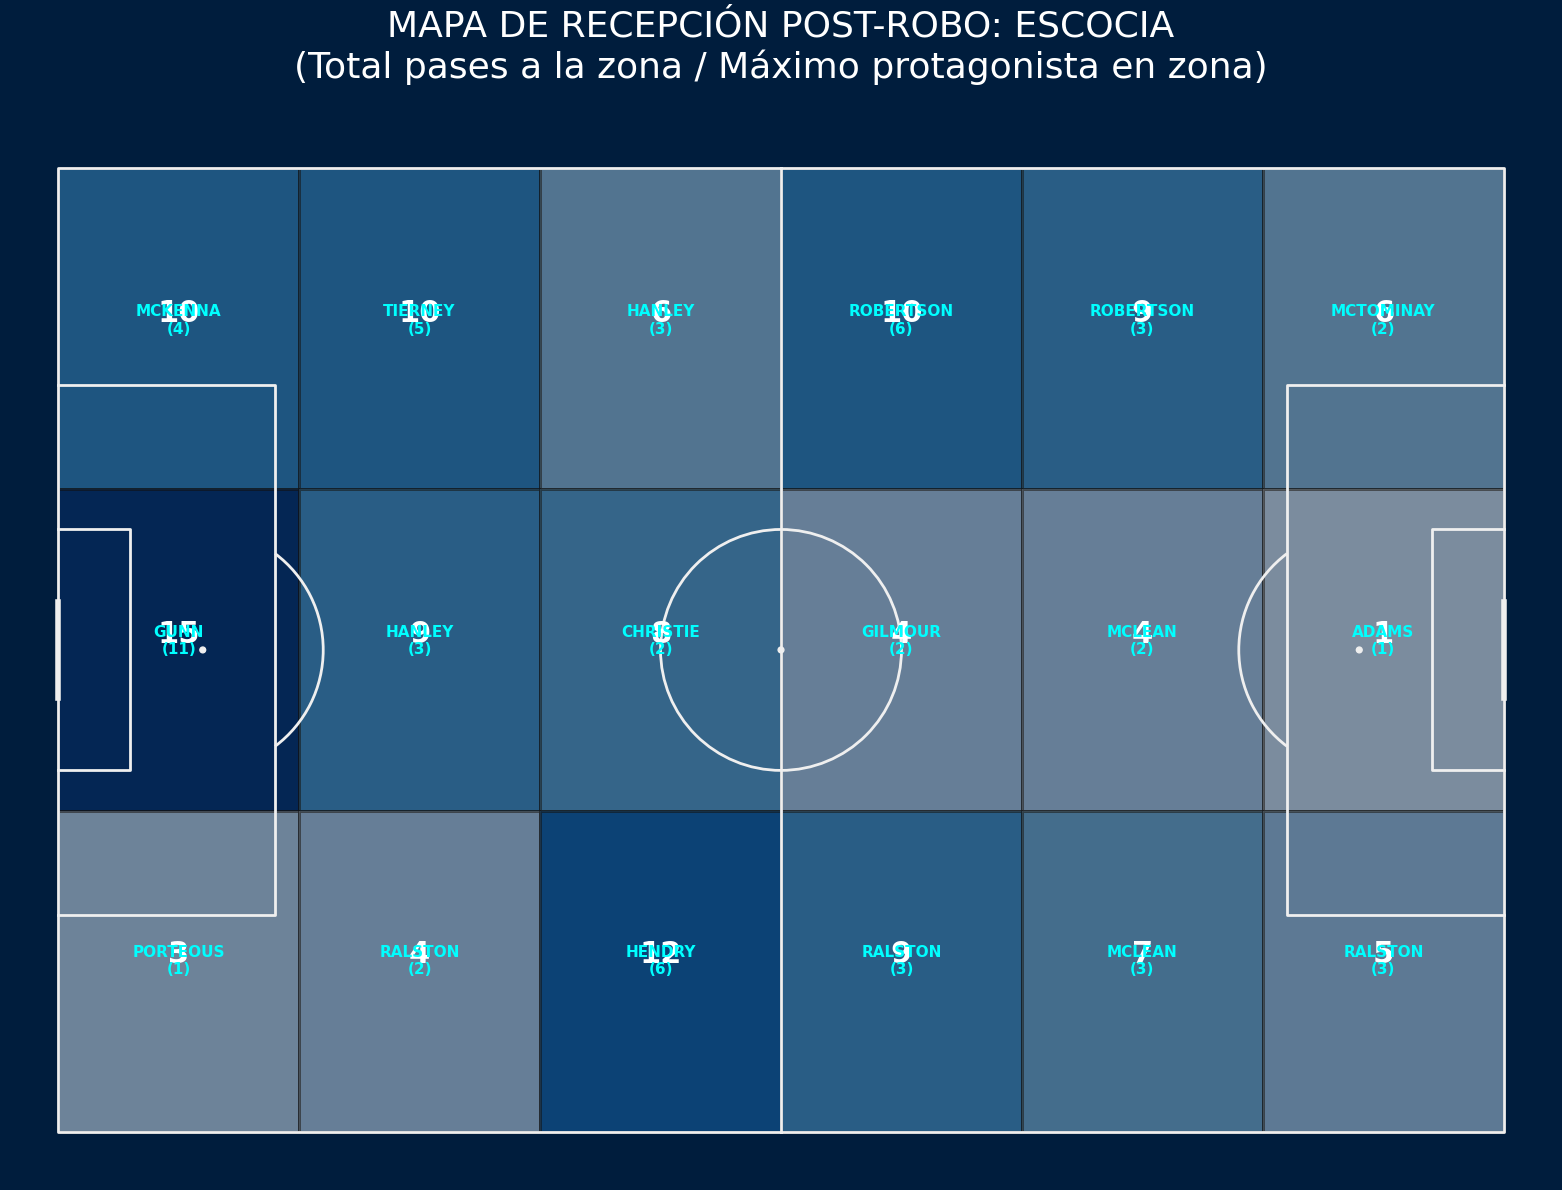

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from mplsoccer import Pitch

# 1. Asegurar que tenemos los datos de transiciones y asignar zonas
if 'trans_df' in locals() and not trans_df.empty:
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(18, 12))

    # Definir los bins (6 horizontales, 3 verticales)
    # x de 0-120, y de 0-80
    bin_statistic = pitch.bin_statistic(trans_df.x_pase_fin, trans_df.y_pase_fin, statistic='count', bins=(6, 3))

    # Dibujar el mapa de calor de fondo (Azules)
    pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='Blues', edgecolors='#111111', alpha=0.5)

    # 2. Lógica para encontrar al máximo receptor por zona
    # Añadimos a qué zona pertenece cada pase final
    trans_df['x_bin'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False)
    trans_df['y_bin'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False)

    # Iterar por cada una de las 18 zonas para poner el texto
    for x_idx in range(6):
        for y_idx in range(3):
            # Filtrar pases que terminaron en esta celda
            subset = trans_df[(trans_df['x_bin'] == x_idx) & (trans_df['y_bin'] == y_idx)]
            total_zona = len(subset)

            if total_zona > 0:
                # Contamos quién recibió más (asumiendo que el receptor es el que está en 'jugador' o 'player')
                # Nota: En StatsBomb, el 'player' del evento Pass es el que PASA.
                # Para saber quién RECIBE, normalmente buscamos el evento 'Ball Receipt*' siguiente.
                # Si no tenemos el receptor exacto, usaremos el que PASÓ para ver quién "limpió" esa zona.

                lider = subset['jugador'].value_counts().idxmax()
                cant_lider = subset['jugador'].value_counts().max()
                apellido = lider.split(' ')[-1].upper()

                # Coordenadas para el texto (centro del bin)
                cx = (x_idx * 20) + 10
                cy = (y_idx * 26.6) + 13.3

                # Texto: Total en grande, Nombre y (Recuperaciones/Pases) abajo
                ax.text(cx, cy, f"{total_zona}", color='white', fontsize=22,
                        fontweight='bold', ha='center', va='bottom')
                ax.text(cx, cy - 2, f"{apellido}\n({cant_lider})", color='#00ffff',
                        fontsize=11, ha='center', va='top', fontweight='semibold')

    plt.title("MAPA DE RECEPCIÓN POST-ROBO: ESCOCIA\n(Total pases a la zona / Máximo protagonista en zona)",
              color='white', fontsize=26, pad=30)
    fig.set_facecolor('#001d3d')
    plt.show()
else:
    print("No hay datos de transiciones. Ejecuta las celdas anteriores primero.")

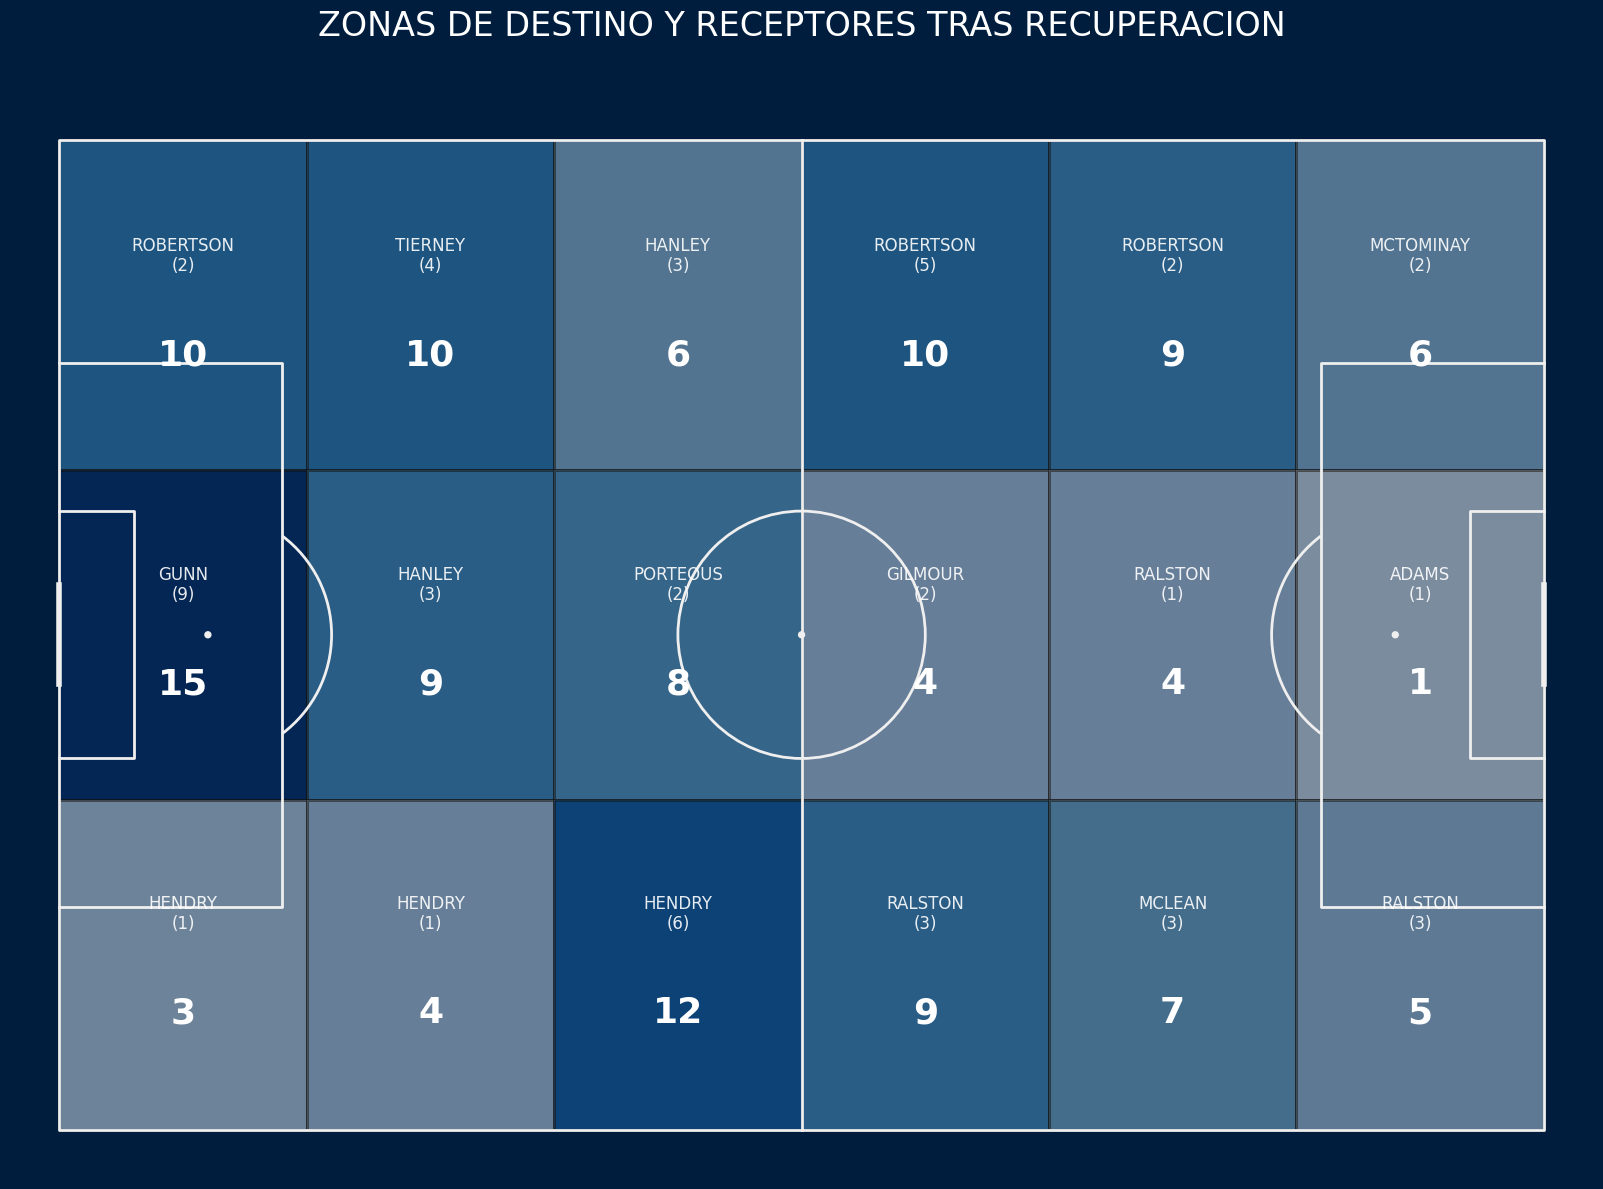

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

if 'trans_df' in locals() and not trans_df.empty:
    # 1. Configurar el campo con 18 zonas (6x3)
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(18, 12))

    # Definir los bins para el cálculo
    bin_statistic = pitch.bin_statistic(trans_df.x_pase_fin, trans_df.y_pase_fin, statistic='count', bins=(6, 3))

    # Dibujar el mapa de calor de fondo en escala de Azules
    pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='Blues', edgecolors='#111111', alpha=0.5)

    # 2. Asignar cada pase a su cuadrante (bin) para identificar al líder
    trans_df['x_bin'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False)
    trans_df['y_bin'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False)

    # 3. Rellenar cada zona con los datos solicitados
    for x_idx in range(6):
        for y_idx in range(3):
            # Filtrar pases en esta zona específica
            subset = trans_df[(trans_df['x_bin'] == x_idx) & (trans_df['y_bin'] == y_idx)]
            total_zona = len(subset)

            if total_zona > 0:
                # Encontrar al jugador con más pases exitosos en esta zona
                # Filtramos solo los exitosos para el nombre del jugador
                exitosos = subset[subset['exito'] == True]

                if not exitosos.empty:
                    lider = exitosos['jugador'].value_counts().idxmax()
                    cant_lider = exitosos['jugador'].value_counts().max()
                    # Tomamos solo el apellido para que no sature visualmente
                    apellido = lider.split(' ')[-1].upper()
                else:
                    apellido = "N/A"
                    cant_lider = 0

                # Calcular centro de la zona para el texto
                cx = (x_idx * 20) + 10
                cy = (y_idx * 26.6) + 13.3

                # --- TEXTOS EN BLANCO ---
                # Número total de pases (Centro arriba)
                ax.text(cx, cy + 4, f"{total_zona}", color='white', fontsize=26,
                        fontweight='bold', ha='center', va='center')

                # Nombre del líder y cantidad (Más abajo del número)
                ax.text(cx, cy - 4, f"{apellido}\n({cant_lider})", color='white',
                        fontsize=12, ha='center', va='center', fontweight='normal', alpha=0.9)

    # 4. Títulos y Estética Final
    plt.title("ZONAS DE DESTINO Y RECEPTORES TRAS RECUPERACION",
              color='white', fontsize=24, pad=40)

    # Añadir una flecha indicando la dirección del ataque
    ax.annotate('', xy=(115, -5), xytext=(5, -5),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))


    fig.set_facecolor('#001d3d')
    plt.show()
else:
    print("No hay datos de transiciones. Por favor, asegúrate de haber ejecutado la lógica de 'trans_df' anteriormente.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

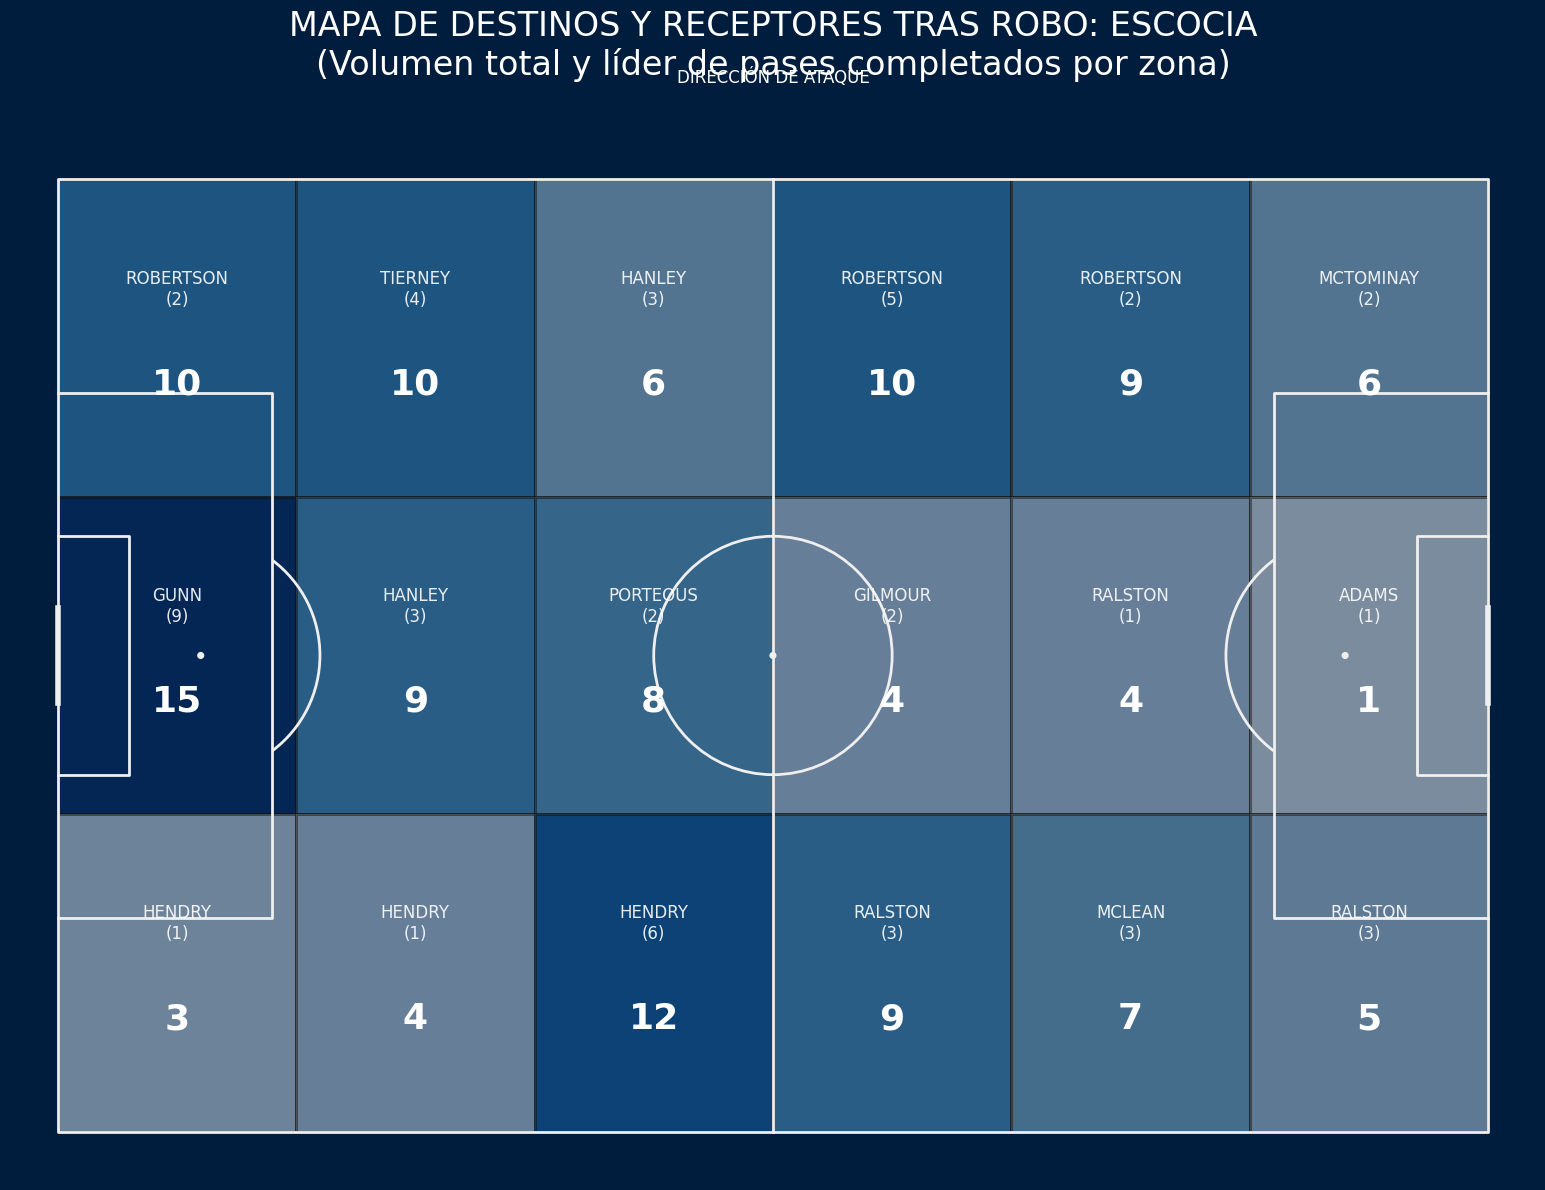

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch
from google.colab import files # Para forzar la descarga directa

if 'trans_df' in locals() and not trans_df.empty:
    # 1. Configurar el campo con 18 zonas (6x3)
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(18, 12))

    # Definir los bins para el cálculo
    bin_statistic = pitch.bin_statistic(trans_df.x_pase_fin, trans_df.y_pase_fin, statistic='count', bins=(6, 3))

    # Dibujar el mapa de calor de fondo en escala de Azules
    pcm = pitch.heatmap(bin_statistic, ax=ax, cmap='Blues', edgecolors='#111111', alpha=0.5)

    # 2. Asignar cada pase a su cuadrante (bin) para identificar al líder
    trans_df['x_bin'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False)
    trans_df['y_bin'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False)

    # 3. Rellenar cada zona con los datos
    for x_idx in range(6):
        for y_idx in range(3):
            subset = trans_df[(trans_df['x_bin'] == x_idx) & (trans_df['y_bin'] == y_idx)]
            total_zona = len(subset)

            if total_zona > 0:
                # Líder de pases exitosos
                exitosos = subset[subset['exito'] == True]
                if not exitosos.empty:
                    lider = exitosos['jugador'].value_counts().idxmax()
                    cant_lider = exitosos['jugador'].value_counts().max()
                    apellido = lider.split(' ')[-1].upper()
                else:
                    apellido = "N/A"
                    cant_lider = 0

                cx = (x_idx * 20) + 10
                cy = (y_idx * 26.6) + 13.3

                # Texto en blanco
                ax.text(cx, cy + 4, f"{total_zona}", color='white', fontsize=26,
                        fontweight='bold', ha='center', va='center')
                ax.text(cx, cy - 4, f"{apellido}\n({cant_lider})", color='white',
                        fontsize=12, ha='center', va='center', fontweight='normal', alpha=0.9)

    # 4. Estética y Títulos
    plt.title("MAPA DE DESTINOS Y RECEPTORES TRAS ROBO: ESCOCIA\n(Volumen total y líder de pases completados por zona)",
              color='white', fontsize=24, pad=40)

    ax.annotate('', xy=(115, -5), xytext=(5, -5),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
    ax.text(60, -8, 'DIRECCIÓN DE ATAQUE', color='white', fontsize=12, ha='center')

    fig.set_facecolor('#001d3d')

    # --- PASO DE DESCARGA AUTOMÁTICA ---
    nombre_archivo = 'destinos_receptores_transicion.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight', facecolor='#001d3d')

    # Esto activará la descarga en tu navegador
    files.download(nombre_archivo)

    # Mostrar

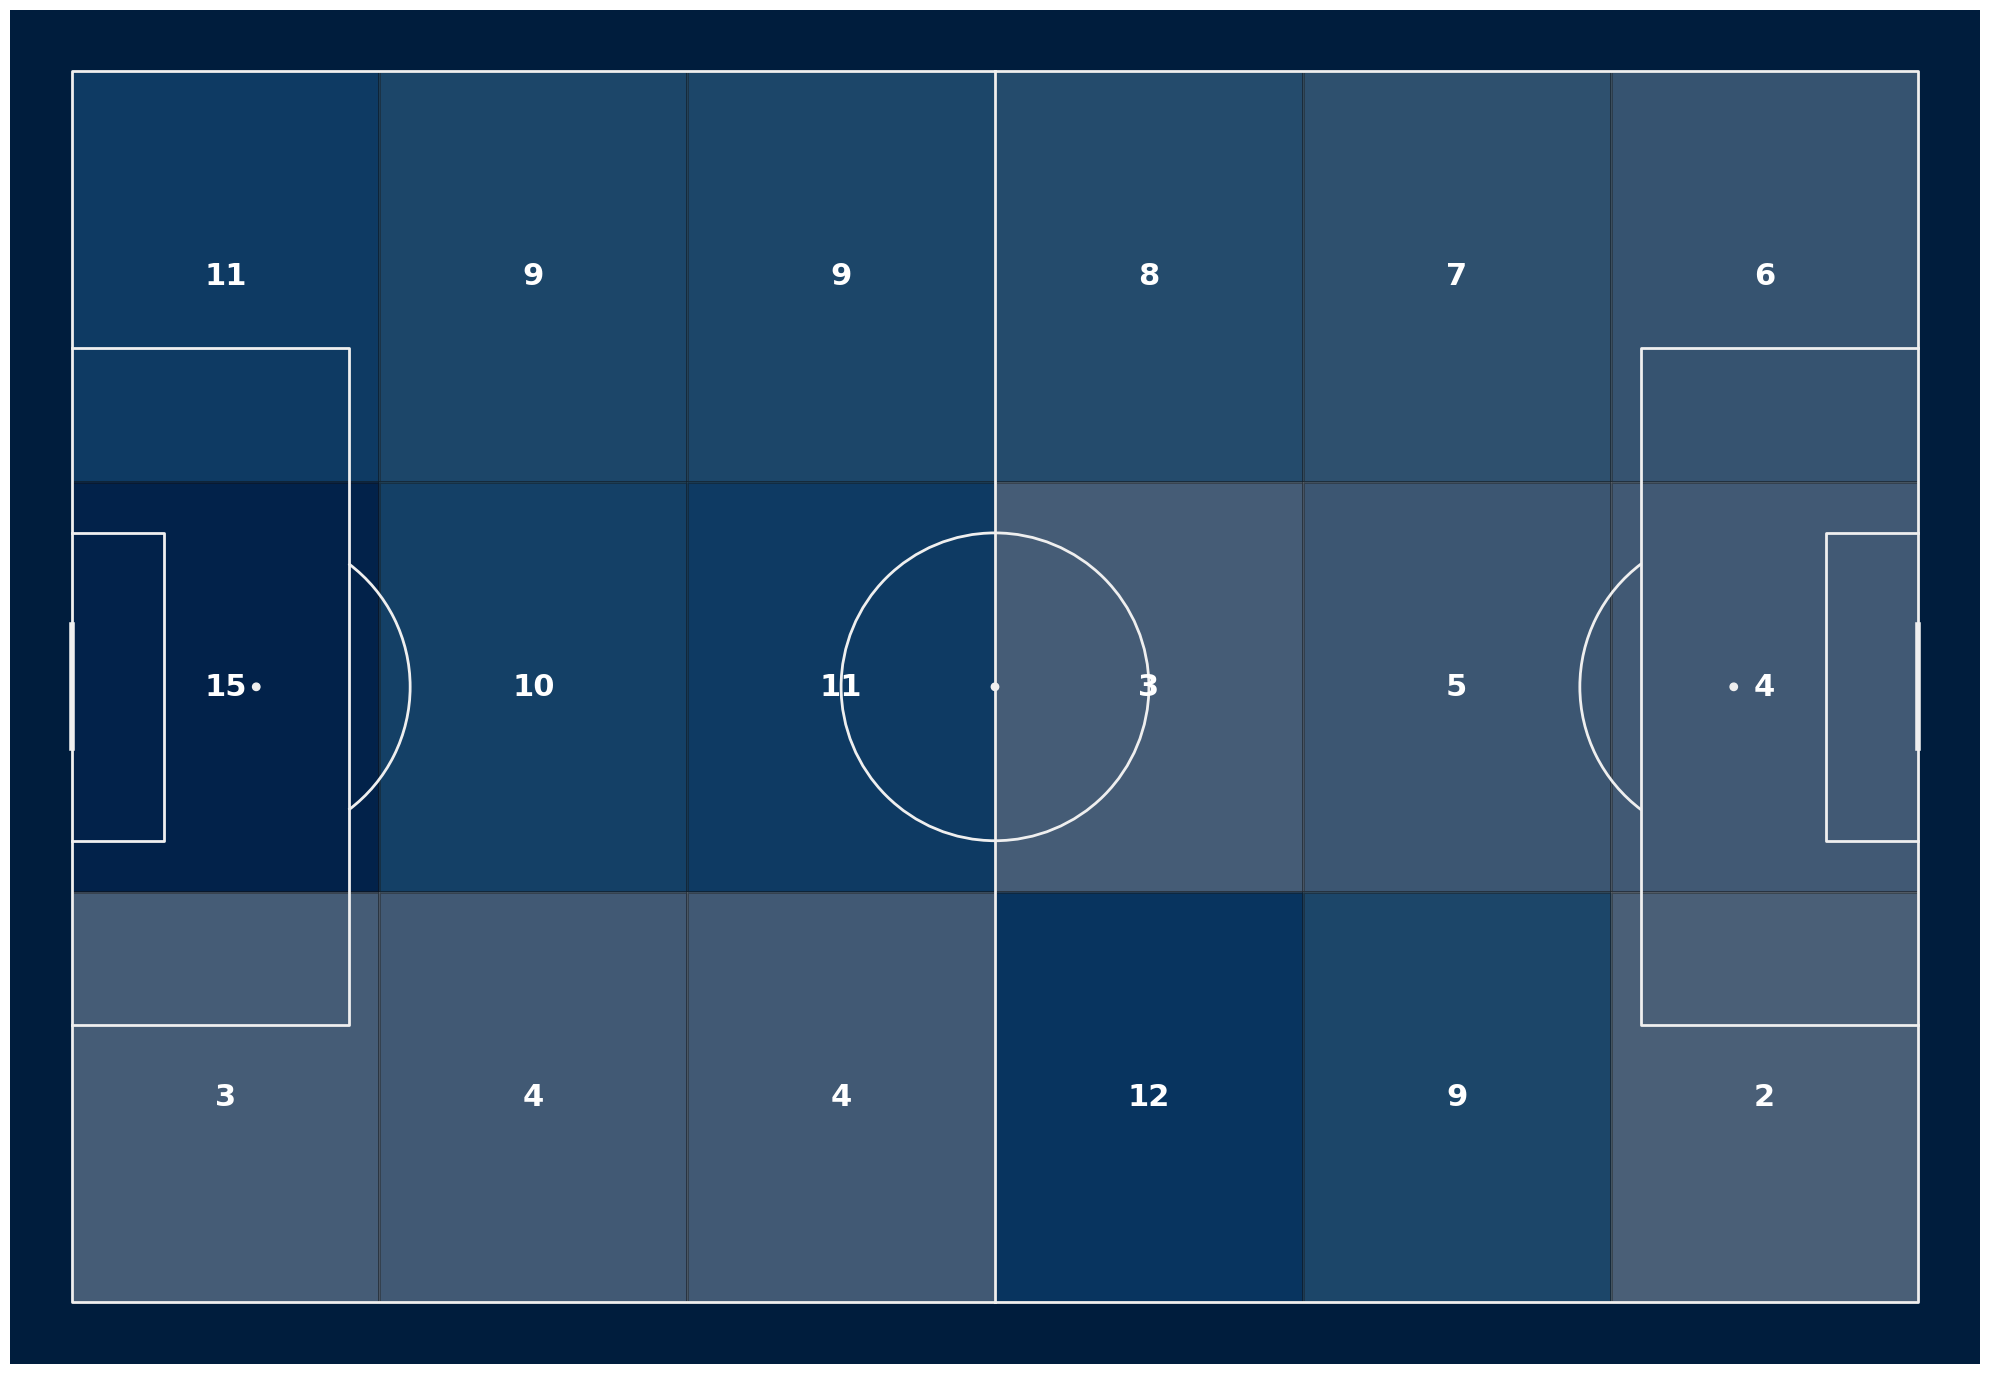

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

if 'trans_df' in locals() and not trans_df.empty:
    # 1. Configurar el campo con 18 zonas (6x3)
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(20, 14))

    # 2. Mapa de Calor de ORIGEN (Donde se recupera)
    bin_statistic = pitch.bin_statistic(trans_df.x_robo, trans_df.y_robo, statistic='count', bins=(6, 3))
    pitch.heatmap(bin_statistic, ax=ax, cmap='Blues', edgecolors='#111111', alpha=0.3)

    # Añadir el número de recuperaciones totales en cada zona (en blanco brillante)
    pitch.label_heatmap(bin_statistic, color='white', fontsize=22, fontweight='bold',
                        ax=ax, str_format='{:.0f}', va='center', ha='center')

    # 3. Lógica de Flechas de Flujo (Agrupadas por Origen -> Destino)
    # Definimos los bins para el robo (origen)

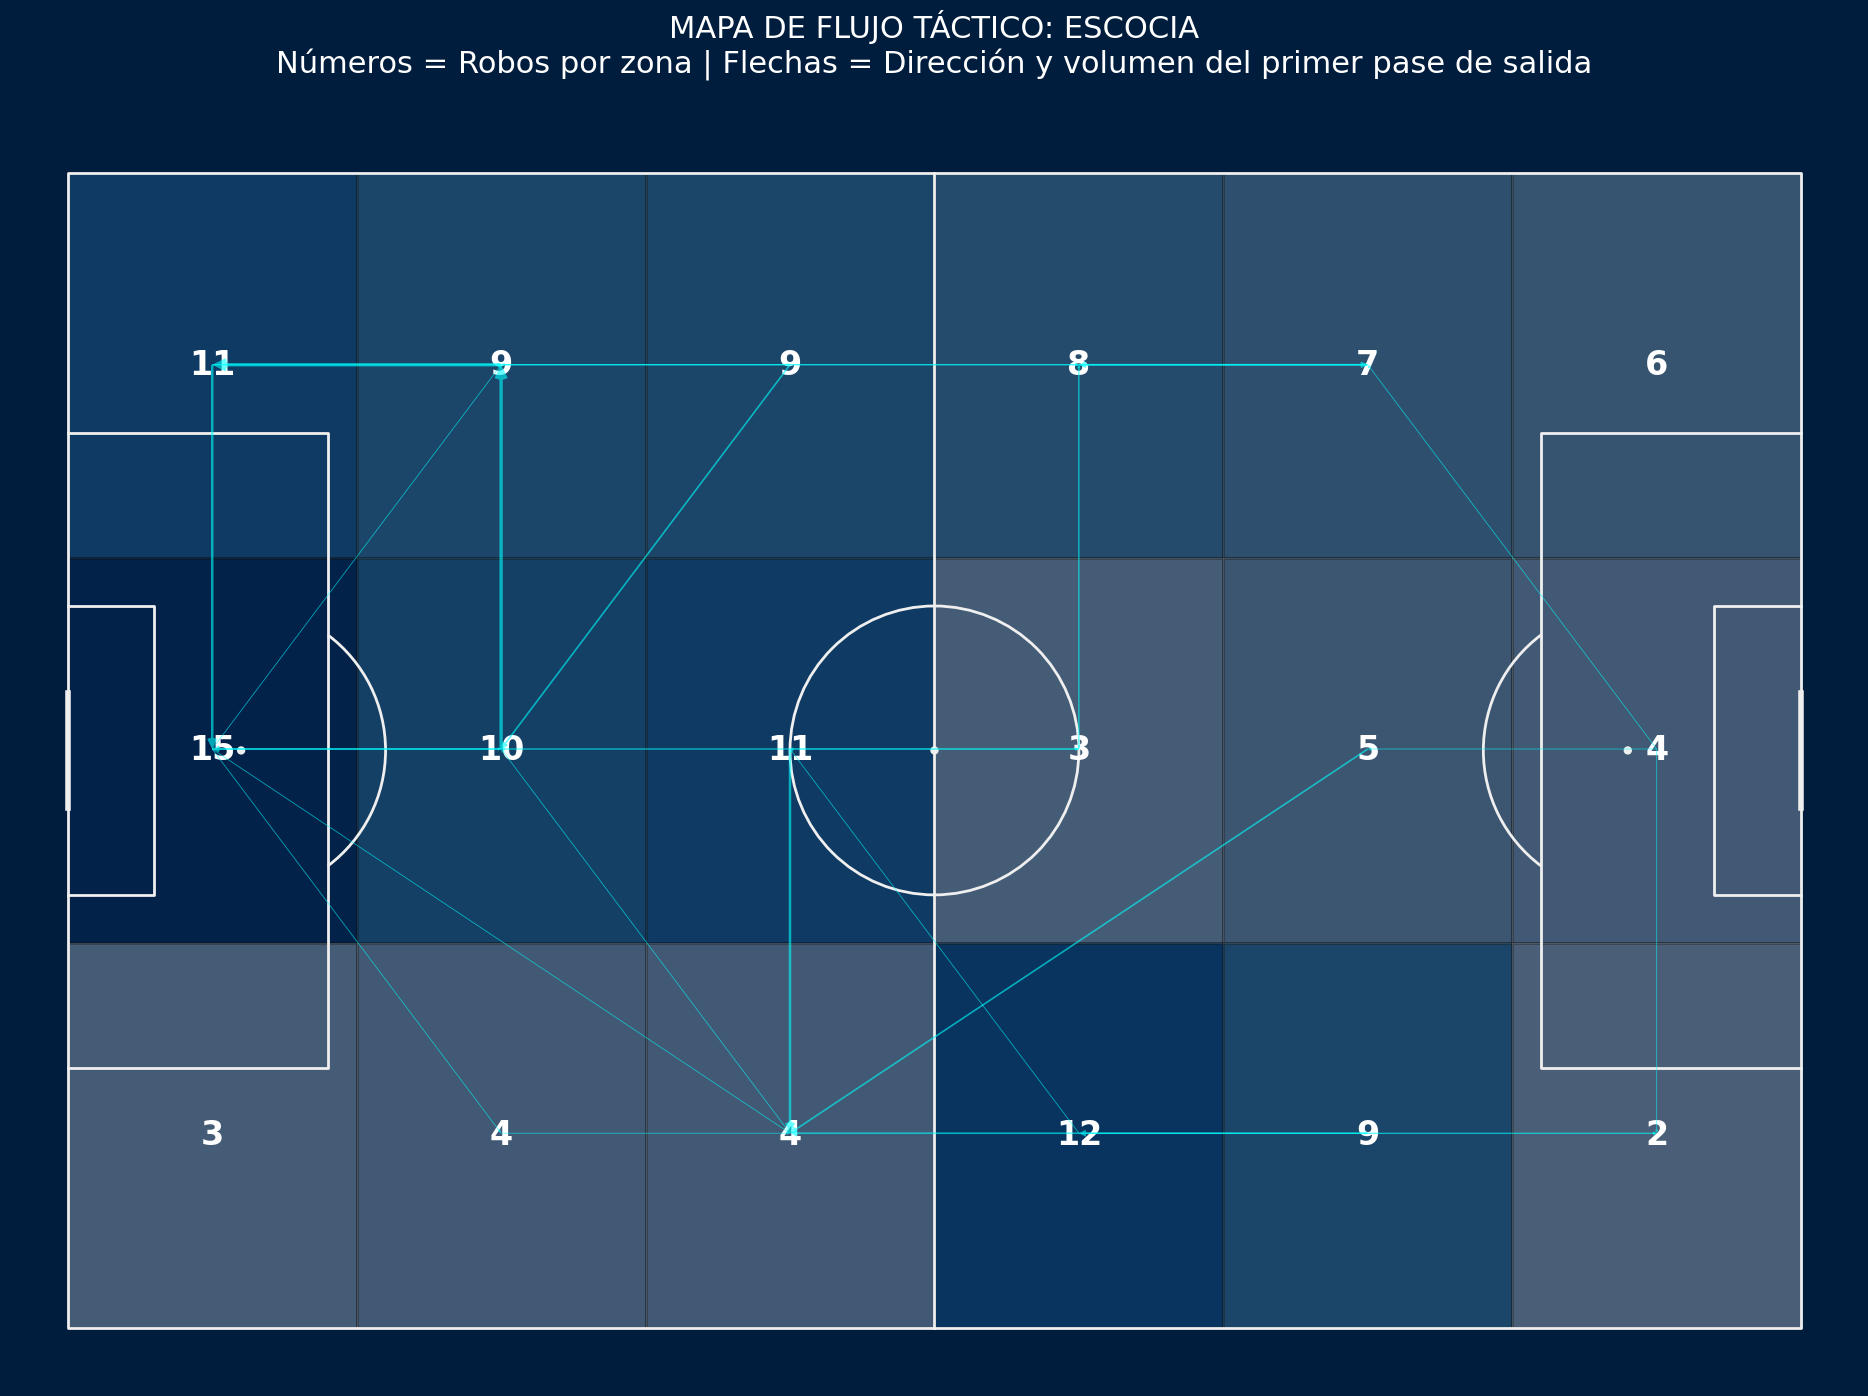

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

# === VERIFICACIÓN Y PREPARACIÓN DE DATOS ===
if 'trans_df' in locals() and not trans_df.empty:
    # 1. Asegurar que tenemos todas las columnas necesarias en trans_df
    # Origen: x_robo, y_robo
    # Destino: x_pase_fin, y_pase_fin

    # 2. Asignar bins de ORIGEN (18 zonas: 6x3) a trans_df
    trans_df['x_bin_origen'] = pd.cut(trans_df['x_robo'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_origen'] = pd.cut(trans_df['y_robo'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)

    # 3. Asignar bins de DESTINO (18 zonas: 6x3) a trans_df
    trans_df['x_bin_destino'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_destino'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)

    # 4. Agrupar para contar cuántos pases van de cada Origen a cada Destino
    # Esto crea la matriz de flujo
    flujos = trans_df.groupby(['x_bin_origen', 'y_bin_origen', 'x_bin_destino', 'y_bin_destino']).size().reset_index(name='cantidad')

    # === VISUALIZACIÓN ===
    # 5. Configurar el campo
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(20, 14))

    # 6. Mapa de calor y números de RECUPERACIONES (Origen)
    # Calculamos la estadística de ORIGEN
    bin_statistic_origen = pitch.bin_statistic(trans_df.x_robo, trans_df.y_robo, statistic='count', bins=(6, 3))

    # Fondo azul sutil para denotar densidad de robos
    pitch.heatmap(bin_statistic_origen, ax=ax, cmap='Blues', edgecolors='#111111', alpha=0.3)

    # Números de robos totales en blanco brillante (Jerarquía visual 1)
    pitch.label_heatmap(bin_statistic_origen, color='white', fontsize=24, fontweight='bold',
                        ax=ax, str_format='{:.0f}', va='center', ha='center')

    # 7. Dibujar FLECHAS DE FLUJO (Jerarquía visual 2)
    # Filtro opcional: Solo mostrar flujos con más de 'N' pases para limpiar
    umbral_limpieza = 1 # Muestra todos. Súbelo a 2 o 3 si hay demasiadas flechas.
    flujos_filtrados = flujos[flujos['cantidad'] >= umbral_limpieza]

    for _, row in flujos_filtrados.iterrows():
        # Coordenadas de inicio (centro del bin de robo)
        start_x = (row['x_bin_origen'] * 20) + 10
        start_y = (row['y_bin_origen'] * 26.6) + 13.3

        # Coordenadas de fin (centro del bin de destino del pase)
        end_x = (row['x_bin_destino'] * 20) + 10
        end_y = (row['y_bin_destino'] * 26.6) + 13.3

        # Evitar flechas que empiezan y terminan en el mismo cuadro (pases muy cortos internos)
        if start_x == end_x and start_y == end_y:
            continue

        # Definir grosor de la flecha proporcional al volumen
        # Ajusta el multiplicador (0.6) para que no salgan flechas gigantes
        grosor = row['cantidad'] * 0.6

        # Color cian vibrante para que contraste con el azul de fondo
        pitch.arrows(start_x, start_y, end_x, end_y,
                     width=grosor, headwidth=4, headlength=4,
                     color='#00ffff', alpha=0.6, ax=ax, zorder=3)

    plt.title("MAPA DE FLUJO TÁCTICO: ESCOCIA\nNúmeros = Robos por zona | Flechas = Dirección y volumen del primer pase de salida",
              color='white', fontsize=22, pad=30)
    fig.set_facecolor('#001d3d')
    plt.show()

else:
    print("Error Crítico: El dataframe 'trans_df' no existe o está vacío. Asegúrate de ejecutar la celda donde se detectan las transiciones tras robo.")

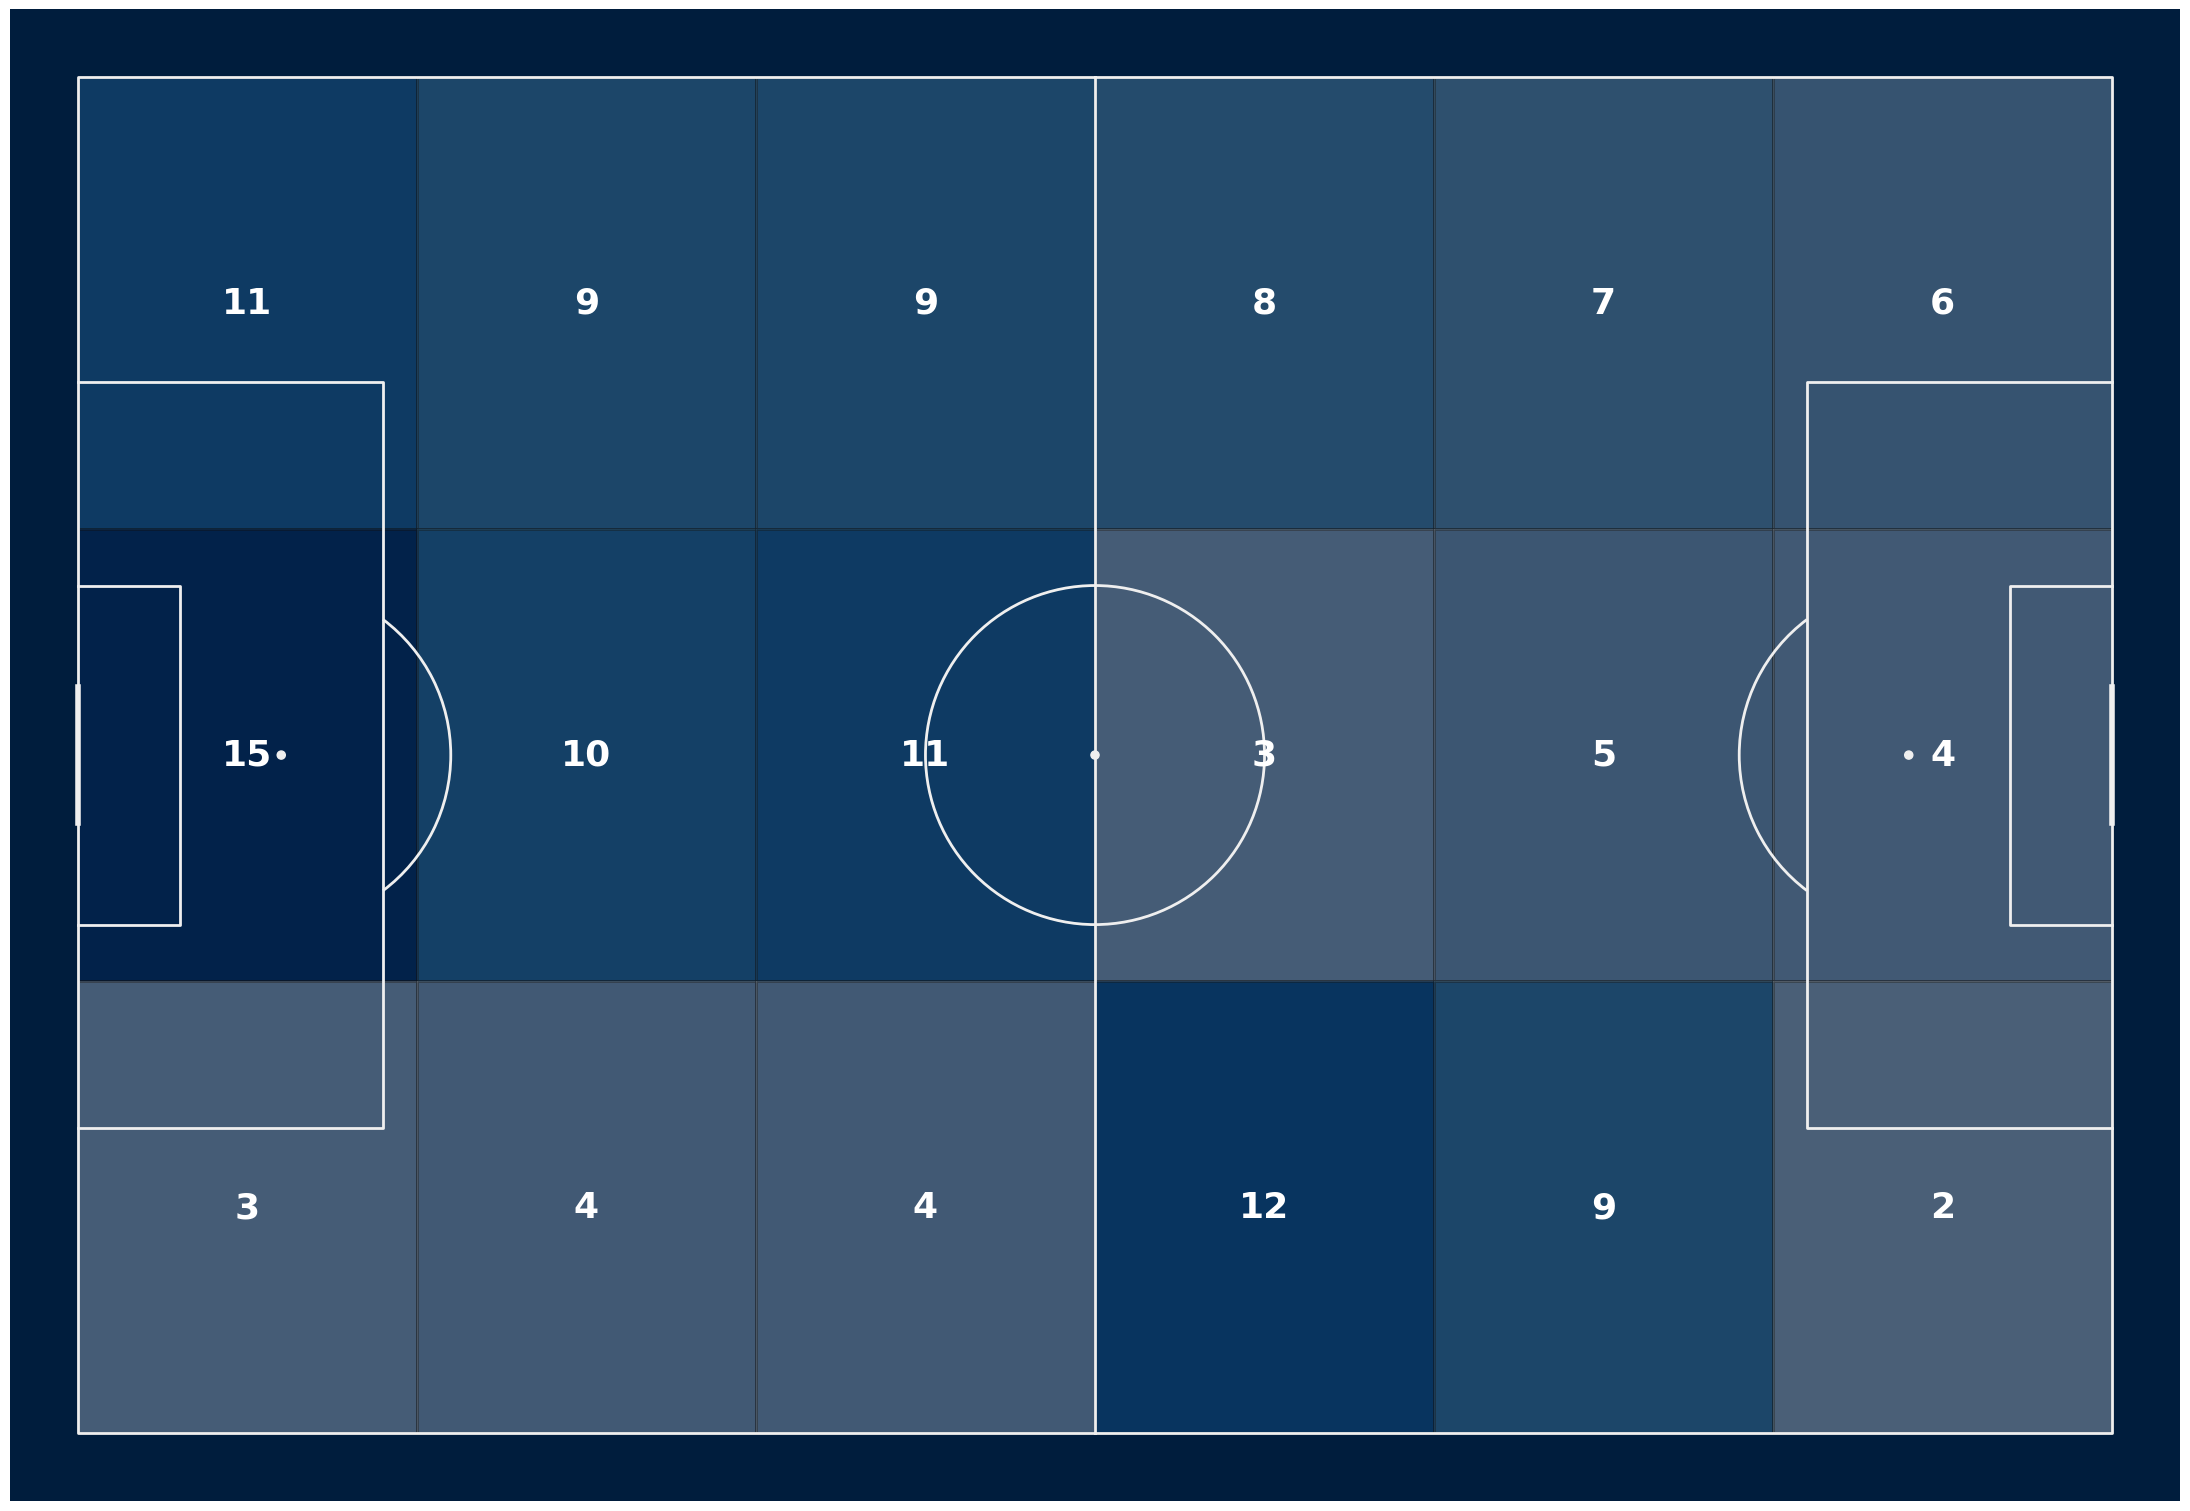

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

# === VERIFICACIÓN Y PREPARACIÓN DE DATOS (Mismo bloque anterior, por seguridad) ===
if 'trans_df' in locals() and not trans_df.empty:
    # 1. Asegurar asignación de Bins (Origen y Destino)
    trans_df['x_bin_origen'] = pd.cut(trans_df['x_robo'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_origen'] = pd.cut(trans_df['y_robo'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)
    trans_df['x_bin_destino'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_destino'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)

    # 2. Agrupar Flujos
    flujos = trans_df.groupby(['x_bin_origen', 'y_bin_origen', 'x_bin_destino', 'y_bin_destino']).size().reset_index(name='cantidad')

    # === VISUALIZACIÓN PULIDA ===
    # 3. Configurar el campo
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='#efefef', line_zorder=2)
    fig, ax = pitch.draw(figsize=(22, 16)) # Aumentamos ligeramente el tamaño para claridad

    # 4. Mapa de calor y números de RECUPERACIONES (Origen)
    bin_statistic_origen = pitch.bin_statistic(trans_df.x_robo, trans_df.y_robo, statistic='count', bins=(6, 3))

    # Fondo azul sutil (DENSIDAD DE ROBO)
    pitch.heatmap(bin_statistic_origen, ax=ax, cmap='Blues', edgecolors='#111111', alpha=0.3)

    # Números de robos totales en blanco (JERARQUÍA 1)
    pitch.label_heatmap(bin_statistic_origen, color='white', fontsize=26, fontweight='bold',
                        ax=ax, str_format='{:.0f}', va='center', ha='center', zorder=4)

    # 5. Dibujar LÍNEAS DE

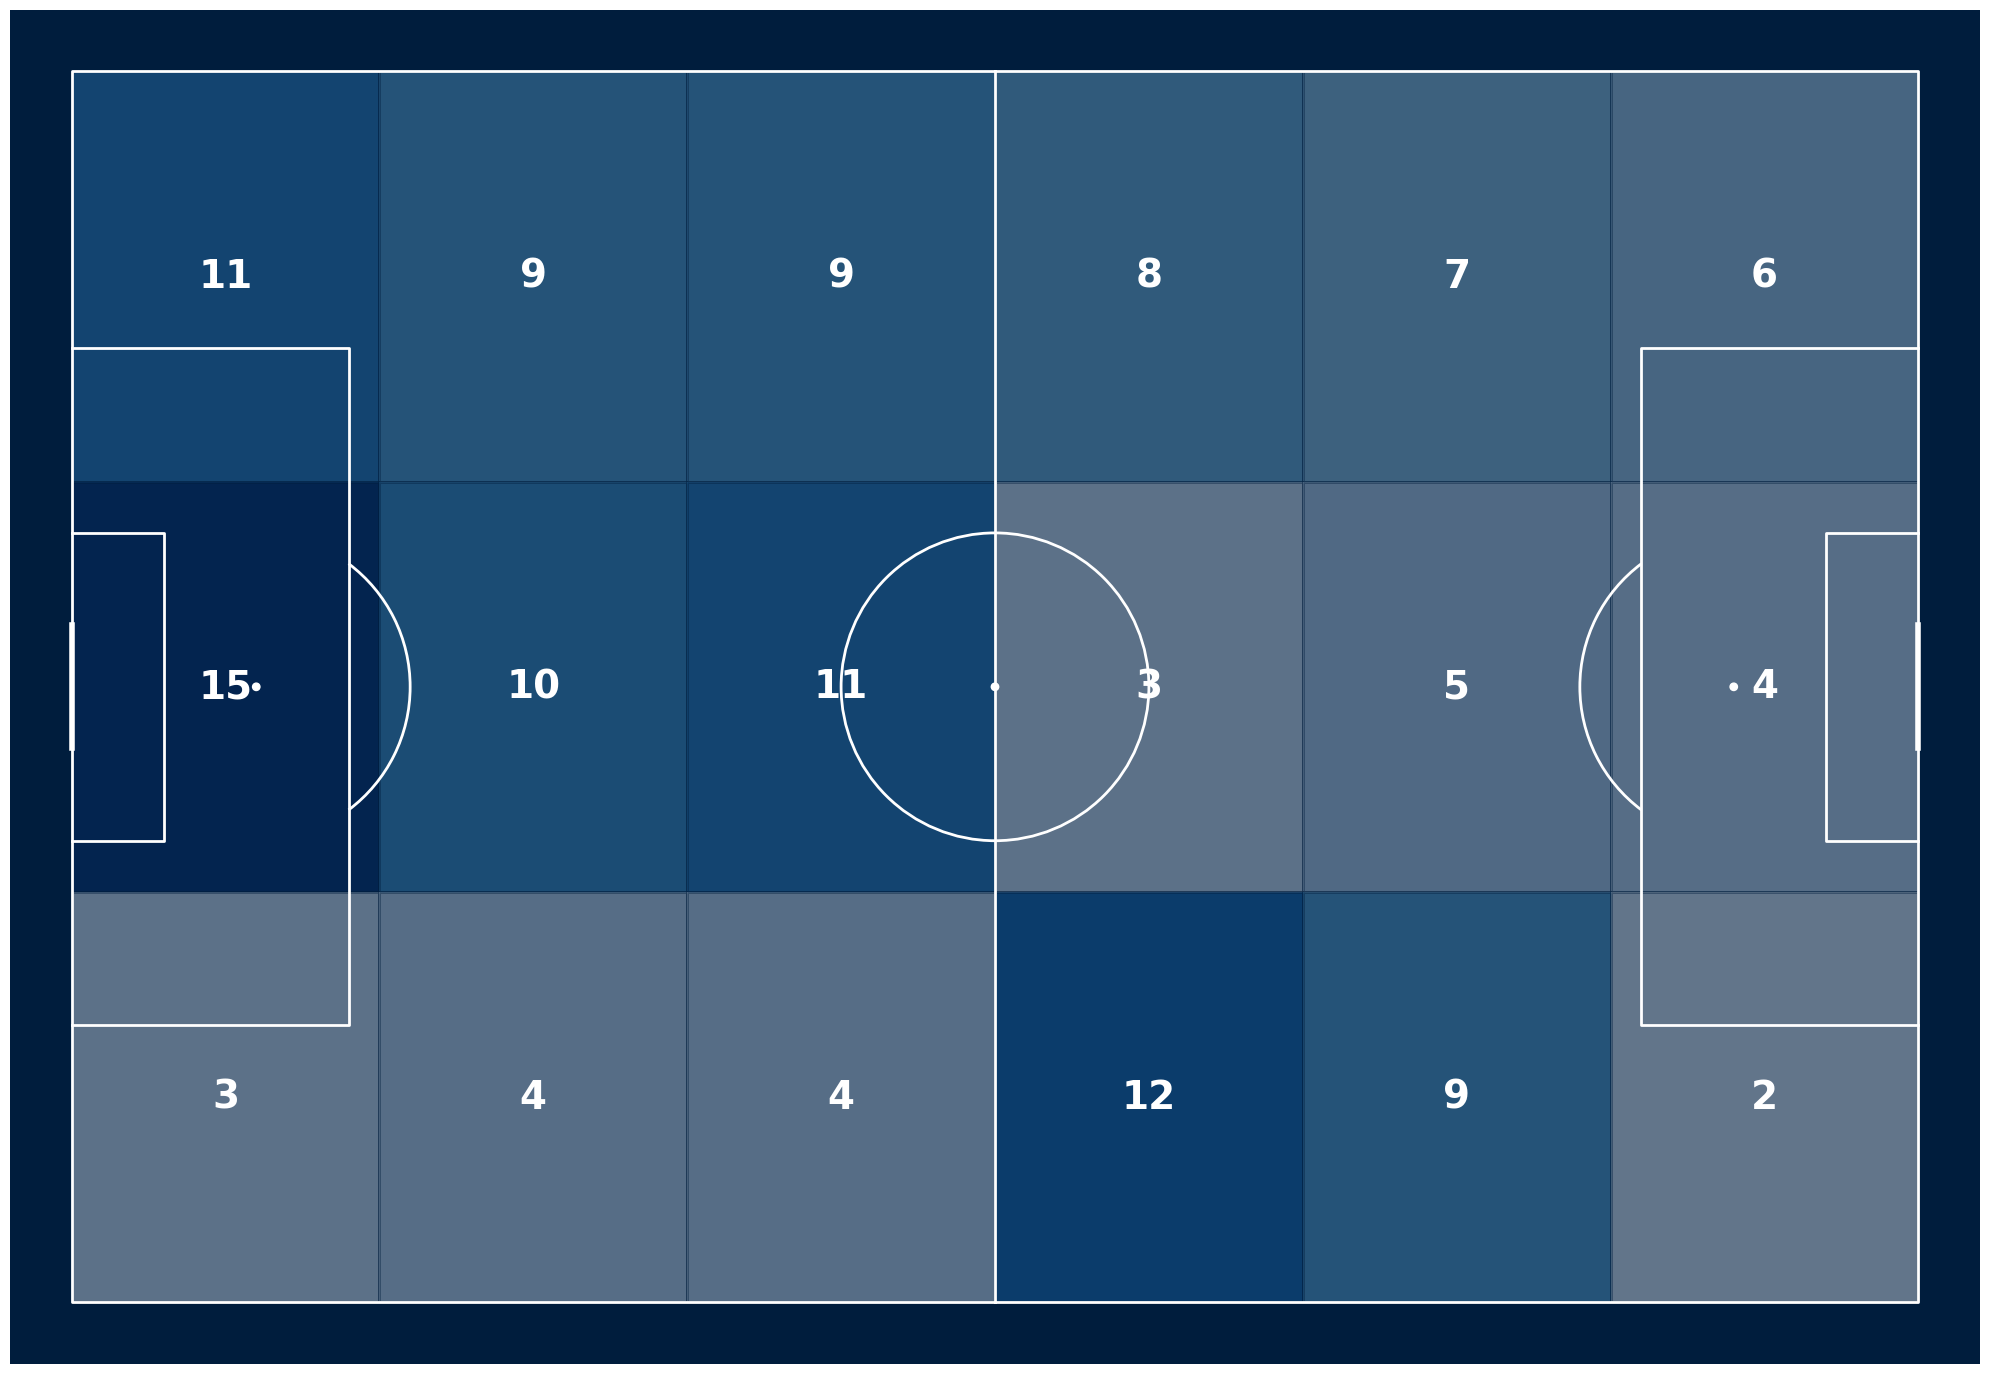

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

if 'trans_df' in locals() and not trans_df.empty:
    # 1. Preparación de Bins (Aseguramos que existan en el dataframe)
    trans_df['x_bin_origen'] = pd.cut(trans_df['x_robo'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_origen'] = pd.cut(trans_df['y_robo'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)
    trans_df['x_bin_destino'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_destino'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)

    # 2. Agrupación de Flujos
    flujos = trans_df.groupby(['x_bin_origen', 'y_bin_origen', 'x_bin_destino', 'y_bin_destino']).size().reset_index(name='cantidad')

    # 3. Configuración del Campo (Líneas más blancas y gruesas)
    # linewidth=2 y line_color='white' para máximo contraste
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='white',
                  linewidth=2, line_zorder=2)
    fig, ax = pitch.draw(figsize=(20, 14))

    # 4. Mapa de calor y números de RECUPERACIONES
    bin_statistic_origen = pitch.bin_statistic(trans_df.x_robo, trans_df.y_robo, statistic='count', bins=(6, 3))

    # Fondo azul un poco más intenso para que resalten los números
    pitch.heatmap(bin_statistic_origen, ax=ax, cmap='Blues', edgecolors='#001d3d', alpha=0.4)

    # Números de robos (Blanco brillante, más grandes)
    pitch.label_heatmap(bin_statistic_origen, color='white', fontsize=28, fontweight='bold',
                        ax=ax, str_format='{:.0f}', va='center', ha='center', zorder=4)

    # 5. Dibujar FLECHAS DE FLUJO (Más gruesas y definidas)
    # Filtramos para mostrar solo flujos representativos (puedes cambiar a 1 para ver todo)
    umbral = 1
    flujos_filtrados = flujos[flujos['cantidad'] >= umbral]

    for _, row in flujos_filtrados.iterrows():
        start_x = (row['x_bin_origen'] * 20) + 10
        start_y = (row['y_bin_origen'] * 26.6) + 13.3

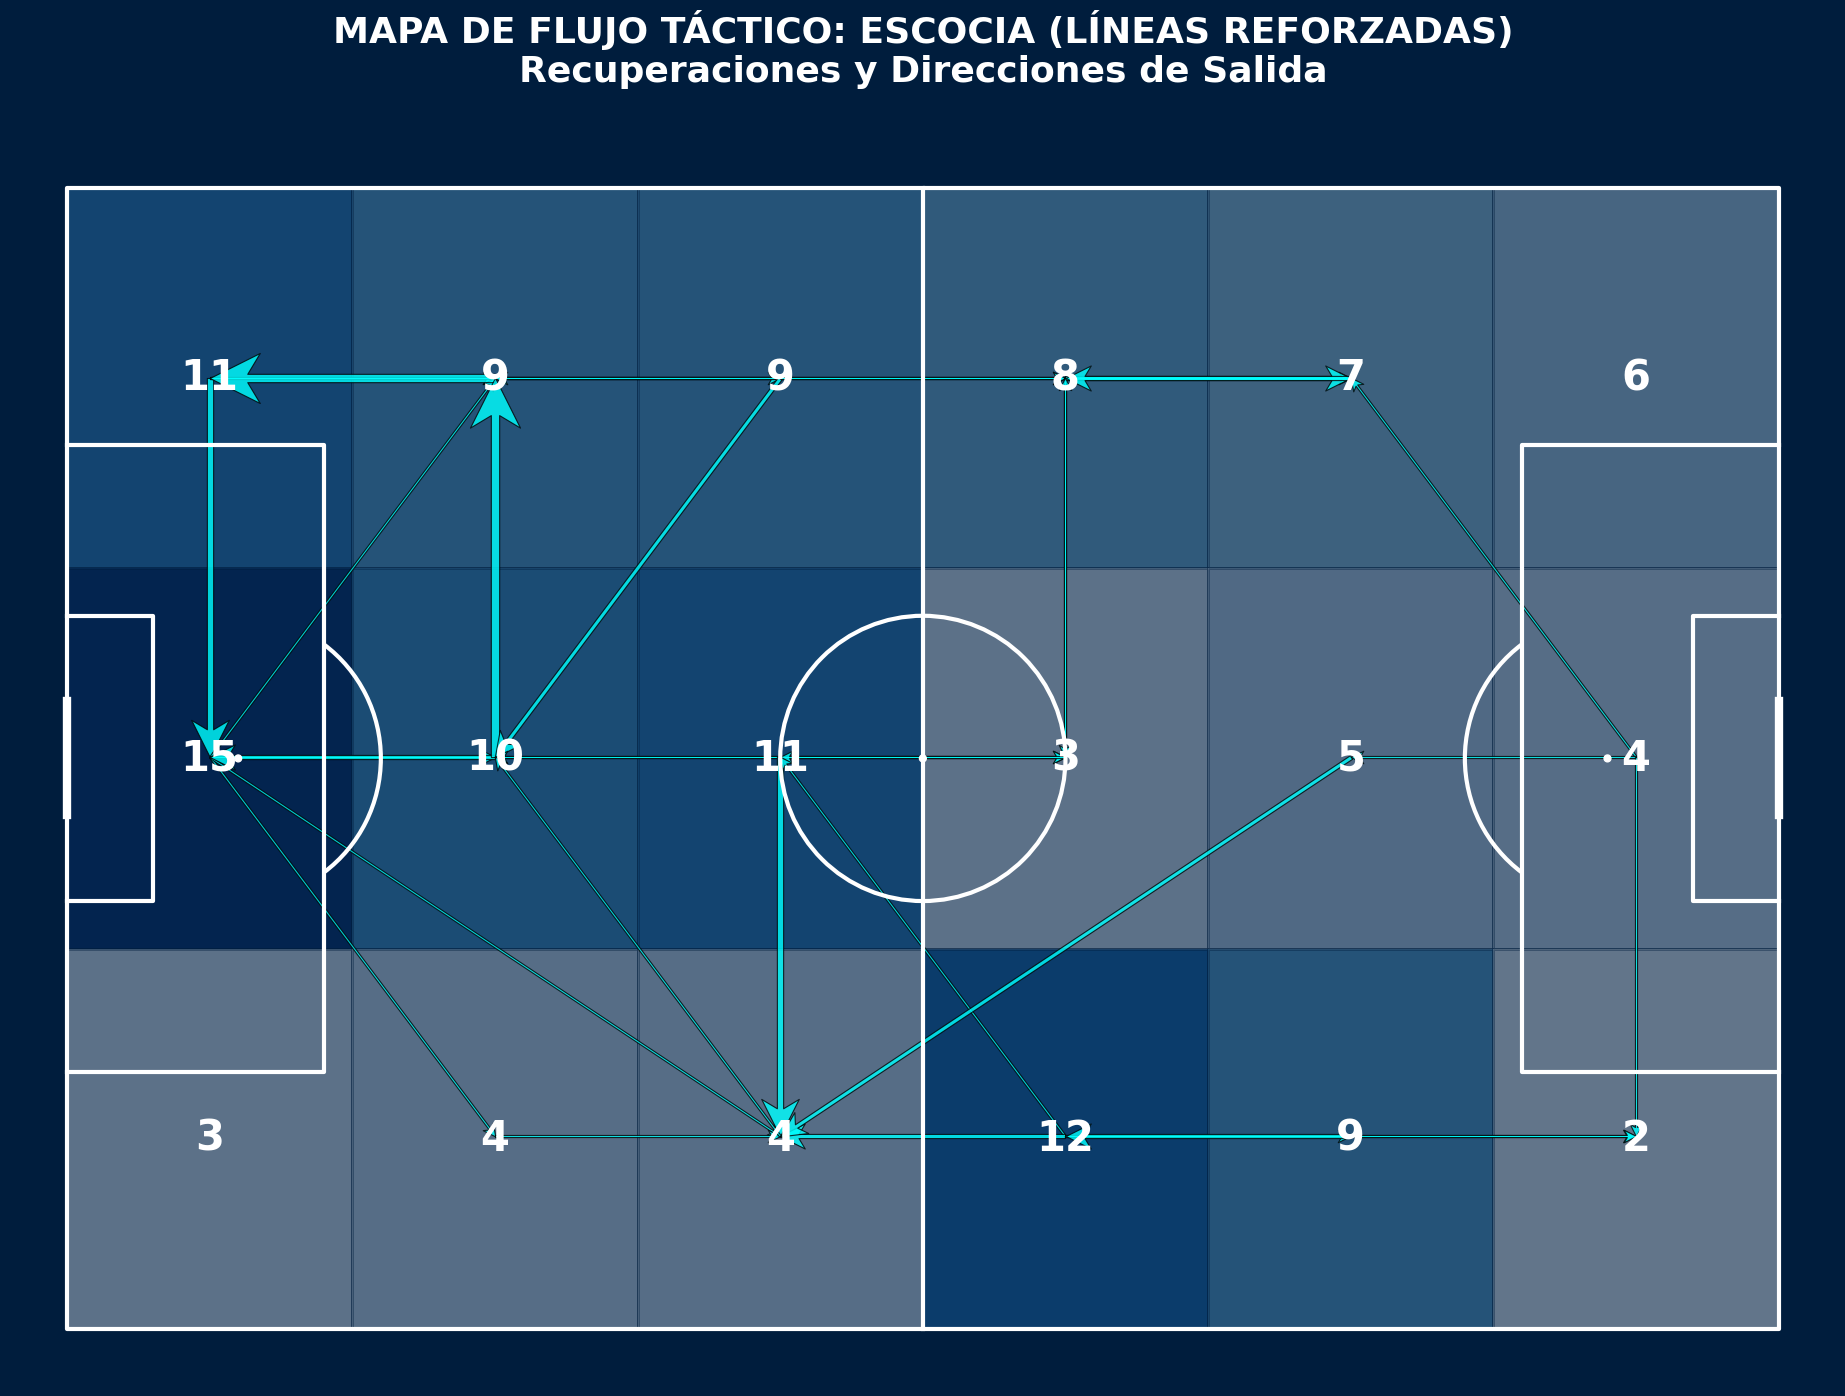

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch

if 'trans_df' in locals() and not trans_df.empty:
    # 1. Preparación de Bins
    trans_df['x_bin_origen'] = pd.cut(trans_df['x_robo'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_origen'] = pd.cut(trans_df['y_robo'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)
    trans_df['x_bin_destino'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_destino'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)

    # 2. Agrupación de Flujos
    flujos = trans_df.groupby(['x_bin_origen', 'y_bin_origen', 'x_bin_destino', 'y_bin_destino']).size().reset_index(name='cantidad')

    # 3. Configuración del Campo (FORZANDO LÍNEAS VISIBLES)
    # Pitch_color es el fondo, line_color es el dibujo del campo
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='white',
                  linewidth=3, line_zorder=5) # Zorder 5 para que esté arriba de todo
    fig, ax = pitch.draw(figsize=(20, 14))

    # 4. Mapa de calor (Zorder bajo para que no tape las líneas)
    bin_statistic_origen = pitch.bin_statistic(trans_df.x_robo, trans_df.y_robo, statistic='count', bins=(6, 3))
    pitch.heatmap(bin_statistic_origen, ax=ax, cmap='Blues', edgecolors='#001d3d', alpha=0.4, zorder=1)

    # 5. Números de robos (Zorder alto)
    pitch.label_heatmap(bin_statistic_origen, color='white', fontsize=30, fontweight='bold',
                        ax=ax, str_format='{:.0f}', va='center', ha='center', zorder=6)

    # 6. Dibujar FLECHAS DE FLUJO
    flujos_filtrados = flujos[flujos['cantidad'] >= 1]

    for _, row in flujos_filtrados.iterrows():
        start_x = (row['x_bin_origen'] * 20) + 10
        start_y = (row['y_bin_origen'] * 26.6) + 13.3
        end_x = (row['x_bin_destino'] * 20) + 10
        end_y = (row['y_bin_destino'] * 26.6) + 13.3

        if start_x == end_x and start_y == end_y:
            continue

        grosor_flecha = row['cantidad'] * 1.5 # Un poco más gruesas

        pitch.arrows(start_x, start_y, end_x, end_y,
                     width=grosor_flecha, headwidth=6, headlength=6,
                     color='#00ffff', edgecolor='black', linewidth=0.8,
                     alpha=0.8, ax=ax, zorder=4)

    plt.title("MAPA DE FLUJO TÁCTICO: ESCOCIA (LÍNEAS REFORZADAS)\nRecuperaciones y Direcciones de Salida",
              color='white', fontsize=26, pad=35, fontweight='bold')

    fig.set_facecolor('#001d3d')
    plt.show()

else:
    print("Error: El dataframe 'trans_df' no tiene datos.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

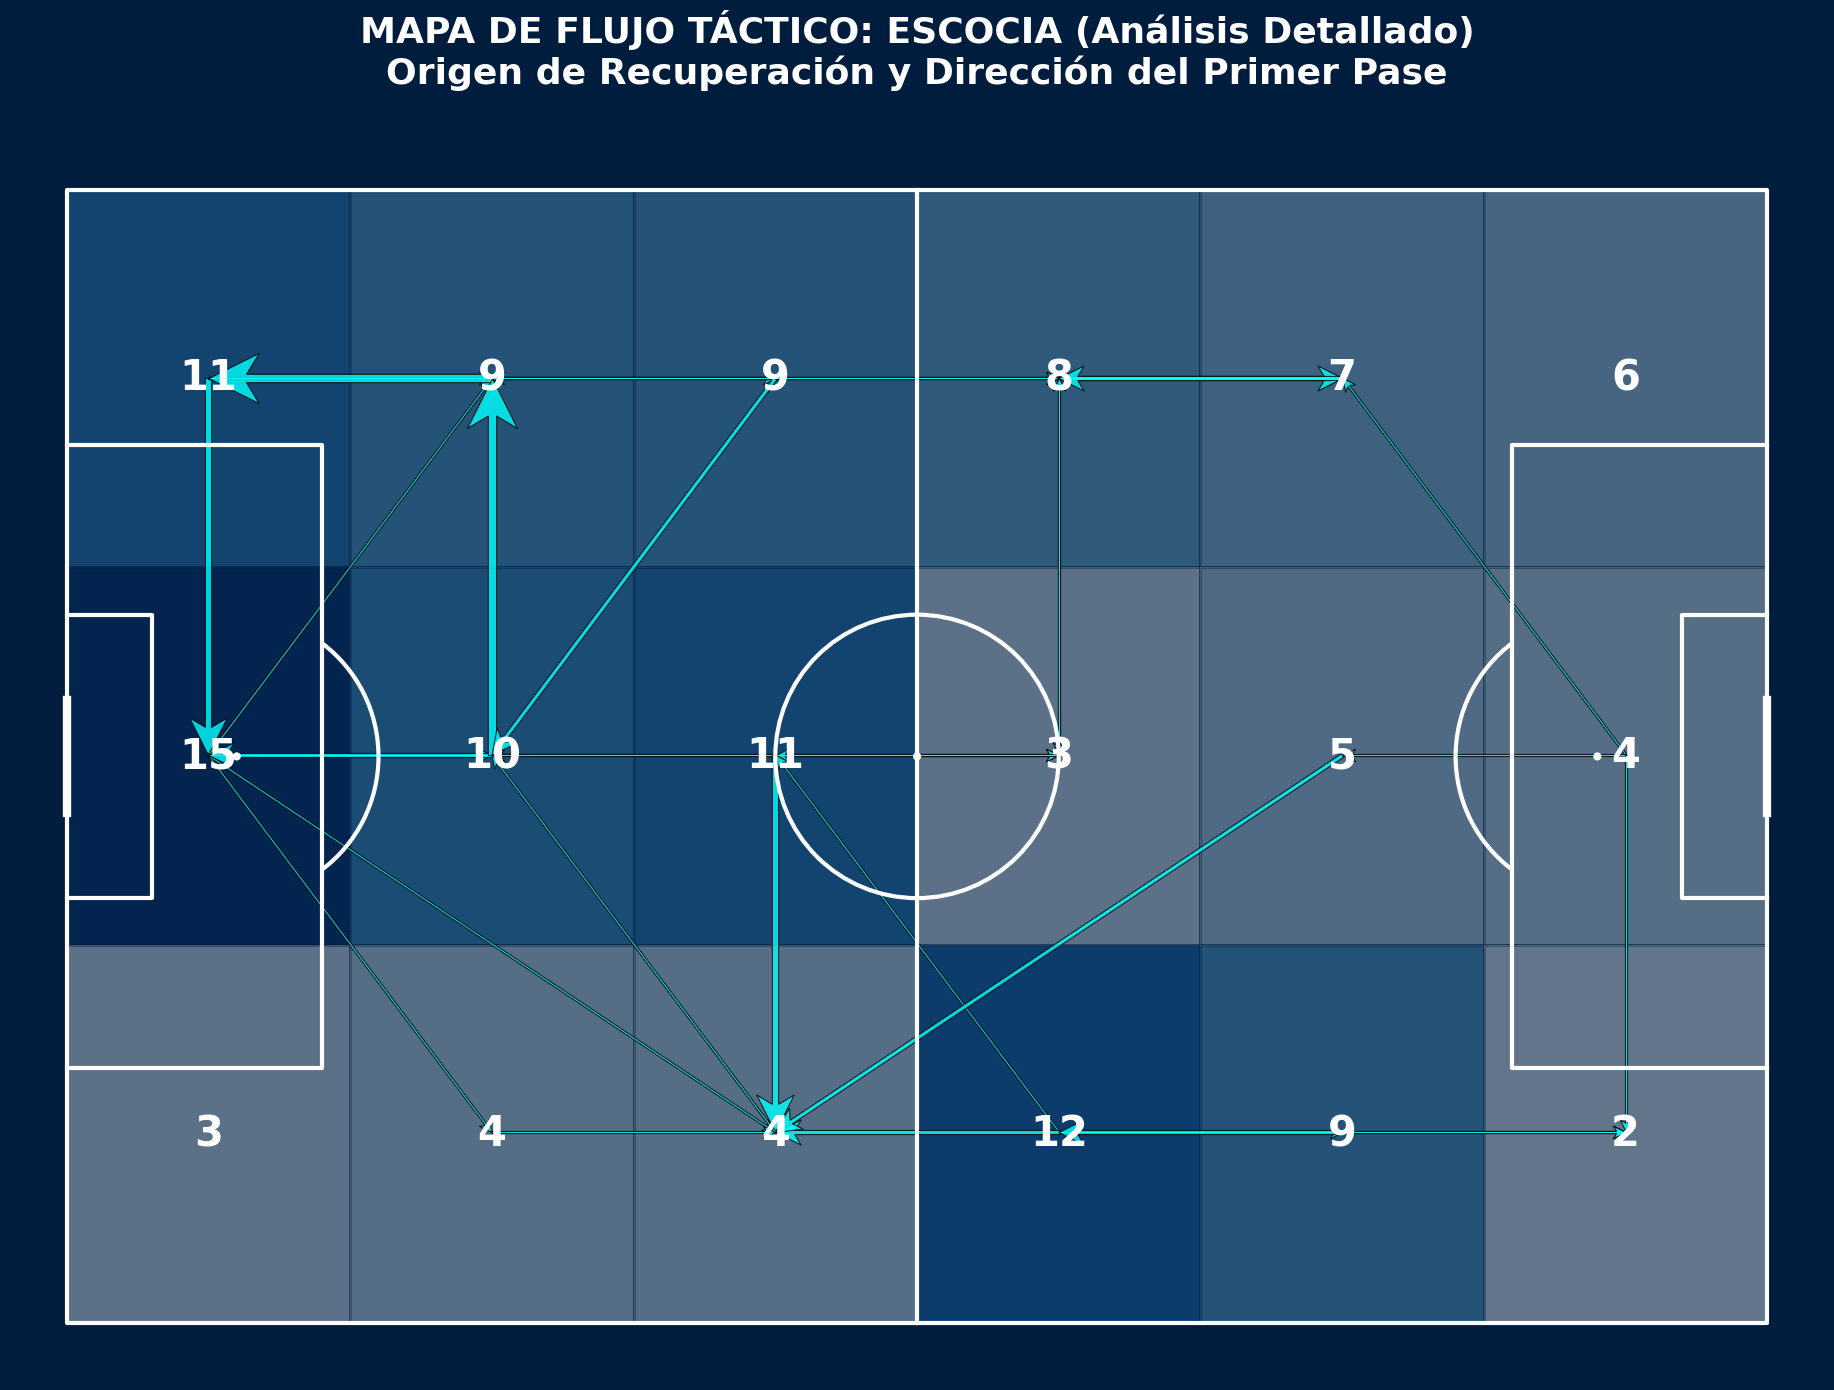

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mplsoccer import Pitch
from google.colab import files # Librería para la descarga automática

if 'trans_df' in locals() and not trans_df.empty:
    # 1. Preparación de Bins (Origen y Destino)
    trans_df['x_bin_origen'] = pd.cut(trans_df['x_robo'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_origen'] = pd.cut(trans_df['y_robo'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)
    trans_df['x_bin_destino'] = pd.cut(trans_df['x_pase_fin'], bins=np.linspace(0, 120, 7), labels=False, include_lowest=True)
    trans_df['y_bin_destino'] = pd.cut(trans_df['y_pase_fin'], bins=np.linspace(0, 80, 4), labels=False, include_lowest=True)

    # 2. Agrupación de Flujos
    flujos = trans_df.groupby(['x_bin_origen', 'y_bin_origen', 'x_bin_destino', 'y_bin_destino']).size().reset_index(name='cantidad')

    # 3. Configuración del Campo (Máximo Contraste)
    # Forzamos line_zorder=5 para que las líneas blancas crucen por encima de los colores
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#001d3d', line_color='white',
                  linewidth=3, line_zorder=5)
    fig, ax = pitch.draw(figsize=(20, 14))

    # 4. Capa de Fondo: Mapa de calor de robos (zorder 1)
    bin_statistic_origen = pitch.bin_statistic(trans_df.x_robo, trans_df.y_robo, statistic='count', bins=(6, 3))
    pitch.heatmap(bin_statistic_origen, ax=ax, cmap='Blues', edgecolors='#001d3d', alpha=0.4, zorder=1)

    # 5. Capa Intermedia: Flechas de transición (zorder 4)
    for _, row in flujos.iterrows():
        start_x = (row['x_bin_origen'] * 20) + 10
        start_y = (row['y_bin_origen'] * 26.6) + 13.3
        end_x = (row['x_bin_destino'] * 20) + 10
        end_y = (row['y_bin_destino'] * 26.6) + 13.3

        # Evitar flechas que empiezan y terminan en el mismo cuadro
        if start_x == end_x and start_y == end_y:
            continue

        grosor_flecha = row['cantidad'] * 1.5

        pitch.arrows(start_x, start_y, end_x, end_y,
                     width=grosor_flecha, headwidth=6, headlength=6,
                     color='#00ffff', edgecolor='black', linewidth=0.8,
                     alpha=0.8, ax=ax, zorder=4)

    # 6. Capa Superior: Números de robos (zorder 6, para que se vean sobre todo)
    pitch.label_heatmap(bin_statistic_origen, color='white', fontsize=30, fontweight='bold',
                        ax=ax, str_format='{:.0f}', va='center', ha='center', zorder=6)

    # 7. Títulos y Estética Final
    plt.title("MAPA DE FLUJO TÁCTICO: ESCOCIA (Análisis Detallado)\nOrigen de Recuperación y Dirección del Primer Pase",
              color='white', fontsize=26, pad=35, fontweight='bold')

    fig.set_facecolor('#001d3d')

    # --- PASO DE DESCARGA AUTOMÁTICA ---
    nombre_archivo = 'matriz_flujos_transicion_escocia.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight', facecolor='#001d3d')

    # Esto activará la descarga en tu navegador
    files.download(nombre_archivo)

    plt.show()

else:
    print("Error: El dataframe 'trans_df' no tiene datos. Asegúrate de que se haya ejecutado la lógica de detección de transiciones.")